# ***Critical Mineral Trades and Uneven Development in the EAC: Evidence from a Structural Outlier(2020–2024)***

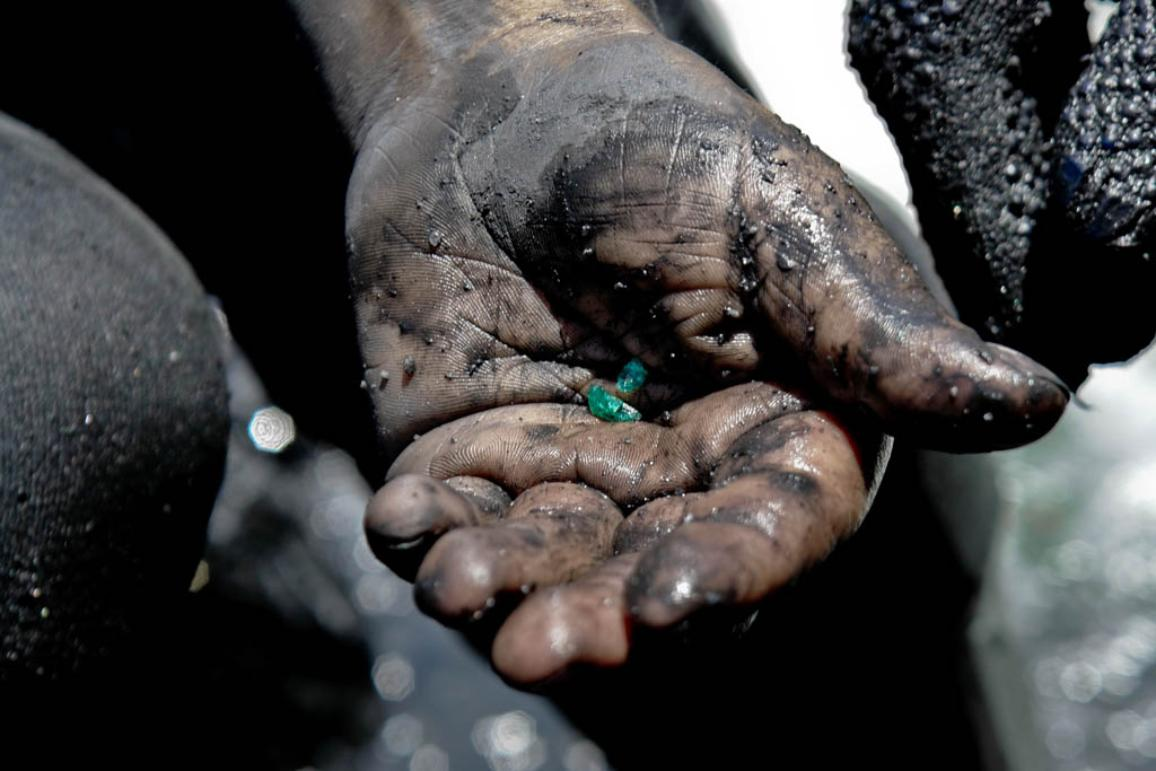

In [13]:
from IPython.display import Image

# The 'r' prefix is the magic trick here
path = r"C:\Users\susan\OneDrive\Desktop\Minerals.jpg"

Image(filename=path)

## Table of Contents
<ul>
  <li><a href="#intro">Introduction</a></li>
  <li><a href="#eda">Exploratory Data Analysis</a></li>
  <li><a href="#conclusions">Conclusions</a></li>
  <li><a href="#bibliography">Bibliography</a></li>
</ul>

# **INTRODUCTION**


The global transition toward renewable energy and low-carbon technologies has dramatically increased demand for critical minerals such as cobalt, copper, lithium, nickel, and rare earth elements. These minerals are essential inputs for batteries, electric vehicles, renewable power systems, and digital infrastructure, positioning mineral-rich regions at the center of a rapidly evolving global economy. Among these regions, Sub-Saharan Africa — and particularly the East African Community (EAC) — has emerged as a strategically vital supplier, with the Democratic Republic of Congo (DRC) alone accounting for over 70% of global cobalt production (IEA, 2023; World Bank, 2020).

Despite this growing global importance, mineral-rich economies in Africa continue to exhibit persistent development challenges, including low industrialization, weak institutional capacity, limited fiscal capture, and high vulnerability to external commodity shocks. This apparent contradiction — whereby countries abundant in natural resources experience slower economic growth and weaker development outcomes — is widely documented in the economic literature as the “resource curse” paradox (Auty, 1993; Sachs & Warner, 2001; Frankel, 2012). Contemporary interpretations emphasize not only governance failures but also structural positioning within global value chains, whereby resource exporters remain locked into low-value extraction segments while downstream processing and technological upgrading occur predominantly in advanced economies (Gereffi & Fernandez-Stark, 2016; UNCTAD, 2020).

In this context, East African mineral exporters face a crucial development challenge: whether the current commodity boom associated with the green transition will enable inclusive economic growth and domestic reinvestment, or instead reinforce historical patterns of extractive dependency and external value capture. While rising mineral exports generate substantial foreign exchange inflows, the degree to which these revenues translate into productive investment, human capital accumulation, and structural transformation remains highly uncertain.

Recent evidence suggests that although extraction volumes and export values have increased significantly across the EAC, particularly in the DRC, domestic development indicators have not kept pace (World Bank, 2022; AfDB, 2023). This disconnect raises important questions regarding how mineral wealth is distributed, reinvested, and transformed into long-term development outcomes.

This analysis investigates the economic impact of critical mineral extraction, trades in five EAC countries — Uganda, Tanzania, Rwanda, Kenya, and the Democratic Republic of Congo — during the period 2020–2024, and with particular focus on the Democratic Republic of Congo (DRC) By integrating physical extraction metrics, trade flow data, and reinvestment proxies, the study aims to empirically assess whether rising mineral activity fosters domestic economic development or primarily benefits external partner economies, particularly Europe and ASEAN.


In [14]:
import pandas as pd
import os

# --- 1. SET THE PATHS ---
# Input Paths (copied from the request)
path_wb_depletion = r"C:\Users\susan\OneDrive\Desktop\API_NY.ADJ.DMIN.GN.ZS_DS2_en_csv_v2_4584\API_NY.ADJ.DMIN.GN.ZS_DS2_en_csv_v2_4584.csv"
path_gtin_depletion = r"C:\Users\susan\OneDrive\Desktop\mineral depletation (%GTIN).csv"
path_rent = r"C:\Users\susan\OneDrive\Desktop\natural resources rent (%of GPD).csv"
path_trade = r"C:\Users\susan\OneDrive\Desktop\trade-as-share-of-gdp\trade-as-share-of-gdp.csv"
path_imports = r"C:\Users\susan\OneDrive\Desktop\merchandise-imports-as-a-share-of-countrys-gdp\merchandise-imports-as-a-share-of-countrys-gdp.csv"
path_services = r"C:\Users\susan\OneDrive\Desktop\service-exports-and-imports-gdp (1)\service-exports-and-imports-gdp.csv"

# Output Path (where the "ready" files will be saved)
output_folder = r"C:\Users\susan\OneDrive\Desktop"

# --- 2. PROCESS WIDE DATA (MELTING) ---

# Processing the World Bank Mineral Depletion File
depletion_df = pd.read_csv(path_wb_depletion, skiprows=4)
year_cols = [col for col in depletion_df.columns if col.isdigit()]
melted_depletion = depletion_df.melt(
    id_vars=['Country Code'], 
    value_vars=year_cols, 
    var_name='Year', 
    value_name='Mineral_Depletion'
)
melted_depletion.to_csv(os.path.join(output_folder, 'mineral_depletion_ready.csv'), index=False)

# Processing the GTIN Mineral Depletion File (also Wide format, semicolon separated)
gtin_df = pd.read_csv(path_gtin_depletion, sep=';', skiprows=4)
year_cols_gtin = [col for col in gtin_df.columns if col.isdigit()]
melted_gtin = gtin_df.melt(
    id_vars=['Country Code'], 
    value_vars=year_cols_gtin, 
    var_name='Year', 
    value_name='Mineral_Depletion_GTIN'
)
melted_gtin.to_csv(os.path.join(output_folder, 'mineral_gtin_ready.csv'), index=False)

# --- 3. PROCESS SEMICOLON DATA ---

# Fix the Semicolon-Separated Rent File
rent_df = pd.read_csv(path_rent, sep=';')
rent_df.to_csv(os.path.join(output_folder, 'natural_resources_rent_ready.csv'), index=False)

# --- 4. STANDARDIZE REMAINING FILES ---

pd.read_csv(path_trade).to_csv(os.path.join(output_folder, 'trade_ready.csv'), index=False)
pd.read_csv(path_imports).to_csv(os.path.join(output_folder, 'imports_ready.csv'), index=False)
pd.read_csv(path_services).to_csv(os.path.join(output_folder, 'services_ready.csv'), index=False)


The following script is designed specifically for the complex structure of the ITC/TradeMap style export uploaded. It solves the "hidden labels" problem by merging the Commodity, the Trade Flow (Export/Import), and the Indicator (FOB/Net Weight) into a single path before melting the data into a long, tidy format.

In [15]:
import pandas as pd
import numpy as np

file_path = r"C:\Users\susan\OneDrive\Desktop\Merchandise_Trade_by_Commodity_HS_2025.csv"
output_file = r"C:\Users\susan\OneDrive\Desktop\Merchandise_Trade_LONG_FORMAT.csv"

# 1. Read the header rows (0 to 4)
# Note: we use sep=';' as identified from the inspection
header_df = pd.read_csv(file_path, sep=';', nrows=5, header=None)

# 2. Forward fill horizontally to handle merged-style headers
header_df = header_df.ffill(axis=1).fillna('')

# 3. Create unique column names
new_columns = []
for i in range(len(header_df.columns)):
    h_parts = [str(header_df.iloc[j, i]).strip() for j in range(5)]
    if i == 0 or 'Time' in h_parts[0]:
        new_columns.append("Period")
    else:
        # Join with a unique separator
        new_columns.append("::".join(h_parts))

# 4. Read the data rows (starting from row 6, skipping row 5 which is Units)
# We skip 6 rows (0-5)
df = pd.read_csv(file_path, sep=';', skiprows=6, header=None, names=new_columns)

# 5. Melt the data
df_long = df.melt(id_vars=['Period'], var_name='Header_Chain', value_name='Value')

# 6. Split the header chain into 5 distinct columns
split_headers = df_long['Header_Chain'].str.split('::', expand=True)

# Assign names
if split_headers.shape[1] >= 5:
    df_long['HS_Commodity'] = split_headers[0]
    df_long['Trade_Flow'] = split_headers[1]
    df_long['Indicator'] = split_headers[2]
    df_long['Reporter_Country'] = split_headers[3]
    df_long['Partner_Country'] = split_headers[4]

# 7. Final Cleanup
df_long = df_long.drop(columns=['Header_Chain'])

# Clean 'Value' column: remove commas and convert to numeric
# Note: some values might use comma as decimal separator based on snippet "92,15"
# Wait, let me check the snippet again. "92,15" vs "278955".
# European style uses comma as decimal. 
# "278955;185000;75440;;;92,15;1560000"
# It looks like ';' is the separator and ',' is the decimal.

def clean_numeric(val):
    if pd.isna(val) or val == '':
        return np.nan
    s = str(val).replace(' ', '').replace(',', '.')
    try:
        return float(s)
    except:
        return np.nan

df_long['Value'] = df_long['Value'].apply(clean_numeric)

# Drop rows with NaN values
df_long = df_long.dropna(subset=['Value'])

# 8. Save
df_long.to_csv(output_file, index=False, encoding='utf-8-sig')

# Display result summary
print(f"Processed rows: {len(df_long)}")
print(df_long.head())

Processed rows: 6896
     Period      Value              HS_Commodity     Trade_Flow  \
0  Jan 2020   278955.0  26 - Ores, slag and ash.  Total Exports   
1  Feb 2020   847917.0  26 - Ores, slag and ash.  Total Exports   
2  Mar 2020   540000.0  26 - Ores, slag and ash.  Total Exports   
3  Apr 2020  1015200.0  26 - Ores, slag and ash.  Total Exports   
4  May 2020   849682.0  26 - Ores, slag and ash.  Total Exports   

        Indicator Reporter_Country               Partner_Country  
0  Net Weight(Kg)         DR Congo  European Union All Countries  
1  Net Weight(Kg)         DR Congo  European Union All Countries  
2  Net Weight(Kg)         DR Congo  European Union All Countries  
3  Net Weight(Kg)         DR Congo  European Union All Countries  
4  Net Weight(Kg)         DR Congo  European Union All Countries  


# **EXPLORATORY DATA ANALYSIS**

# 1. Loading and understanding the data structure
        - Reading data by using pd.read_csv() and getting further df.info()
        - Perform basic commands like .describe(), df.dtypes and .head() to understand the dataset's shape, data types, and get a quick overview
        - Take a look at all the columns in the df
        - Save a copy of the raw dataframe as a new df.raw = df.copy()
        
> dataset: `East_African_Community_(EAC)_dataset_final.csv`

## Key information in East African Community dataset: ##

- `Country` & `Year` (The Identifiers): These are the index variables. They tell "Who" and "When."

Thesis Significance: They allow you to perform Time-Series Cross-Sectional (Panel Data) analysis. You can compare how Kenya progressed from 2000 to 2024 versus how Tanzania or Rwanda progressed in that same timeframe.

- `Commodity`: The specific type of mineral or good being traded (e.g., Gold, Copper, Tin).

Thesis Significance: This allows for Sectoral Analysis. You can identify if a country’s economic health is too dependent on a single mineral (concentration risk).

- `Physical Extraction Intensity`: This measures the total volume of raw materials extracted from the environment relative to the size of the economy.

Thesis Significance: This is a "Resource Efficiency" indicator. A high intensity means the economy is heavily reliant on "digging things up" to grow, which is often considered environmentally unsustainable.

- `Total_Trade_GDP`: Also known as the "Trade Openness Ratio" it is the sum of Exports and Imports divided by the country's total GDP.

Thesis Significance: It shows how integrated a country is into the global market. In the EAC, this helps you see if regional integration (the EAC trade bloc) is actually increasing trade levels for member states.

- `Natural_Resource_Rents (% of GDP)`: This is the "profit" a country makes from its natural resources (Oil, Gas, Minerals, Forests). It is calculated as the difference between the price of the resource and the cost of extracting it.

Thesis Significance: High rents indicate a "Resource Rich" economy. This is often used to study the "Resource Curse"—where countries with high rents sometimes experience slower industrial growth in other sectors.

- `Mineral_Depletion_GNI & GTIN`: `GNI` (Gross National Income) measures the loss of future income caused by extracting minerals today. It treats natural resources like capital that is being "spent." `GTIN` (Total Indicator) likely represents the absolute value or a specific index of that depletion.

Thesis Significance: This is a "Sustainability" metric. It tells you if a country is getting rich by "exhausting its future." If Mineral Depletion is high but the money isn't being reinvested in education or infrastructure, the country's long-term wealth is actually shrinking.

In [16]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns

from IPython.display import display
%matplotlib inline
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as tls

import warnings
warnings.filterwarnings('ignore')

In [17]:
file_path = r'C:\Users\susan\OneDrive\Desktop\East_African_Community_(EAC)_dataset_final.csv'

# Add the 'sep' argument to tell pandas to look for semicolons
EAC_community_df = pd.read_csv(file_path, sep=';') 

EAC_community_df_raw = EAC_community_df.copy()

In [18]:
EAC_community_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        455 non-null    object 
 1   Year                           455 non-null    int64  
 2   Commodity                      325 non-null    object 
 3   Physical_Extraction_Intensity  325 non-null    float64
 4   Total_Trade_GDP                455 non-null    object 
 5   Natural_Resource_Rents         392 non-null    float64
 6   Mineral_Depletion_GNI          392 non-null    float64
 7   Mineral_Depletion_GTIN         392 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 28.6+ KB


In [19]:
EAC_community_df.head()

,Country,Year,Commodity,Physical_Extraction_Intensity,Total_Trade_GDP,Natural_Resource_Rents,Mineral_Depletion_GNI,Mineral_Depletion_GTIN
0,Democratic Republic of Congo,2024,Copper,513.0,97.494.644,NaN,NaN,NaN
1,Democratic Republic of Congo,2024,Gold,3046349.0,97.494.644,NaN,NaN,NaN
2,Democratic Republic of Congo,2024,Zinc,71.0,97.494.644,NaN,NaN,NaN
3,Democratic Republic of Congo,2024,Tin,2231.0,97.494.644,NaN,NaN,NaN
4,Democratic Republic of Congo,2024,Lead,50.0,97.494.644,NaN,NaN,NaN


In [20]:
EAC_community_df.tail()

,Country,Year,Commodity,Physical_Extraction_Intensity,Total_Trade_GDP,Natural_Resource_Rents,Mineral_Depletion_GNI,Mineral_Depletion_GTIN
450,Uganda,1964,NaN,NaN,52.993.984,NaN,NaN,NaN
451,Uganda,1963,NaN,NaN,52.171.486,NaN,NaN,NaN
452,Uganda,1962,NaN,NaN,4.555.512,NaN,NaN,NaN
453,Uganda,1961,NaN,NaN,46.062.096,NaN,NaN,NaN
454,Uganda,1960,NaN,NaN,49.145.832,NaN,NaN,NaN


In [21]:
EAC_community_df.describe()

,Year,Physical_Extraction_Intensity,Natural_Resource_Rents,Mineral_Depletion_GNI
count,455.000000,3.250000e+02,3.920000e+02,392.000000
mean,2001.252747,6.213547e+05,2.424419e+07,1.110535
std,16.339995,1.226051e+06,2.060518e+07,2.886114
min,1960.000000,7.000000e+00,4.120500e+04,0.000000
25%,1993.500000,5.000000e+01,6.851581e+06,0.005716
50%,2004.000000,5.130000e+02,2.034076e+07,0.081492
75%,2014.000000,2.237800e+04,3.629903e+07,0.956733
max,2024.000000,3.046349e+06,1.255621e+08,22.660362


In [22]:
EAC_community_df.dtypes

Country                           object
Year                               int64
Commodity                         object
Physical_Extraction_Intensity    float64
Total_Trade_GDP                   object
Natural_Resource_Rents           float64
Mineral_Depletion_GNI            float64
Mineral_Depletion_GTIN            object
dtype: object

In [23]:
EAC_community_df[['Commodity', 'Country']].nunique()

Commodity    8
Country      5
dtype: int64

In [24]:
EAC_community_df.Commodity.unique()

array(['Copper', 'Gold', 'Zinc', 'Tin', 'Lead', 'Aluminum', nan, 'Silver',
       'Nickel'], dtype=object)

In [25]:
EAC_community_df.Country.unique()

array(['Democratic Republic of Congo', 'Kenya', 'Rwanda', 'Tanzania',
       'Uganda'], dtype=object)

In [26]:
# Standardize the name in the Country column for Tanzania (The official name is 'United Republic of Tanzania'), and DRC (with DR Congo):
name_map = {
    'Tanzania': 'United Republic of Tanzania',
    'DRC': 'DR Congo'
}

EAC_community_df['Country'] = EAC_community_df['Country'].map(name_map).fillna(EAC_community_df['Country'])
print(EAC_community_df['Country'].unique().tolist())

['Democratic Republic of Congo', 'Kenya', 'Rwanda', 'United Republic of Tanzania', 'Uganda']


In [27]:
EAC_community_df.Year.unique()

array([2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014,
       2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003,
       2002, 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992,
       1991, 1990, 1989, 1988, 1987, 1986, 1985, 1984, 1983, 1982, 1981,
       1980, 1979, 1978, 1977, 1976, 1975, 1974, 1973, 1972, 1971, 1970,
       1969, 1968, 1967, 1966, 1965, 1964, 1963, 1962, 1961, 1960])

In [28]:
EAC_community_df.shape

(455, 8)

In [29]:
EAC_community_df.columns

Index(['Country', 'Year', 'Commodity', 'Physical_Extraction_Intensity',
       'Total_Trade_GDP', 'Natural_Resource_Rents', 'Mineral_Depletion_GNI',
       'Mineral_Depletion_GTIN'],
      dtype='object')

# 2. Data Cleaning & Treatment
         • Check for missing values using df.isnull().sum()
         • Use df.duplicated().sum() to check for duplicate records that could skew your analysis
         • Look for inconsistencies in categorical variables (e.g., "Male" vs "M" vs "male"), typing errors
         • Validate data ranges --> taking a look at all of the columns within the dataset to make sure to understand all of the content and correct any errors in the values; check for outliers; choosing the columns to keep; rename columns if needed; drop columns if they're not showing valuable information; deciding to fill or drop null values; normalize data if needed (np.log)
         • For numerical variables: Consider mean/median imputation.
         • For categorical variables: Mode imputation or creating a new "Missing" category
# 3. Outlier Detection & Treatment
         • Use statistical methods: IQR method (1.5 * IQR rule) and z-score method (typically ±3 standard deviations)
         • Always investigate outliers before removal - they might contain valuable business insights
         • Consider capping outliers at percentiles instead of removing them completely (Functions_EDA)
         • For numerical variables: Consider mean/median imputation.
         • For categorical variables: Mode imputation or creating a new "Missing" category

In [30]:
import sys

# Add the folder containing Functions_EDA.py to Python path
sys.path.insert(0, r'C:\Users\susan\Downloads\_DA_course-20251106T182827Z-1-001\_DA_course\_functions_')

# Import all functions from the module
from Functions_EDA import *

In [31]:
EAC_community_df.isnull().sum()

Country                            0
Year                               0
Commodity                        130
Physical_Extraction_Intensity    130
Total_Trade_GDP                    0
Natural_Resource_Rents            63
Mineral_Depletion_GNI             63
Mineral_Depletion_GTIN            63
dtype: int64

In [32]:
EAC_community_df.duplicated().sum()

np.int64(0)

In [33]:
help(percentage_nullValues)

Help on function percentage_nullValues in module Functions_EDA:

percentage_nullValues(data)
    Function that calculates the percentage of missing values in every column of your dataset
    input: data --> dataframe



In [34]:
percentage_nullValues(EAC_community_df)

,Percentage_NaN
Physical_Extraction_Intensity,28.6
Commodity,28.6
Mineral_Depletion_GNI,13.8
Natural_Resource_Rents,13.8
Mineral_Depletion_GTIN,13.8
Year,0.0
Country,0.0
Total_Trade_GDP,0.0


In [35]:
help(select_threshold)

Help on function select_threshold in module Functions_EDA:

select_threshold(data, thr)
    Function that  calculates the percentage of missing values in every column of your dataset
    input: data --> dataframe



In [36]:
EAC_community_df = select_threshold(EAC_community_df, 30)

Columns to keep: 8
Those columns have a percentage of NaN less than 30 :
['Physical_Extraction_Intensity', 'Commodity', 'Mineral_Depletion_GNI', 'Natural_Resource_Rents', 'Mineral_Depletion_GTIN', 'Year', 'Country', 'Total_Trade_GDP']


Since column "Total_Trade_GDP"  is an "object," it likely contains characters like %, commas, or spaces. We will strip those out and convert it to a number:

In [37]:
# 1. Remove non-numeric characters (like %, commas, spaces)
EAC_community_df['Total_Trade_GDP'] = EAC_community_df['Total_Trade_GDP'].astype(str).str.replace('%', '', regex=False)
EAC_community_df['Total_Trade_GDP'] = EAC_community_df['Total_Trade_GDP'].str.replace(',', '', regex=False).str.strip()

# 2. Convert to numeric (errors='coerce' turns ".." or "N/A" into NaN)
EAC_community_df['Total_Trade_GDP'] = pd.to_numeric(EAC_community_df['Total_Trade_GDP'], errors='coerce')

# Check the result
print(EAC_community_df['Total_Trade_GDP'].dtype) # Should now be float64

float64


In [38]:
help(fill_na)

Help on function fill_na in module Functions_EDA:

fill_na(data)
    Function to fill NaN with mode (categorical variabls) and mean (numerical variables)
    input: data -> df



## Handling NaNs (Missing Values)
Since the missing data is less than 30%, it is recommended to fill (Imputation) rather than dropping. If I drop 30% of my rows, I would lose a significant portion of the "story," especially in a small dataset of 455 rows.

The decision: Grouped Median Filling 

In economic data, filling with the overall mean is bad because Rwanda and Kenya have very different scales. It is better to fill missing values with the Median of that specific country.

I applied a "Loop" approach to handle all these columns at once. Since the columns are numeric, the Grouped Median is the safest way to maintain the integrity of each country's economic profile.

N.B. I converted the columns to float64 before calling .median()

For the Commodity column (which is text/categorical), because the median can't be used, a mode will be used instead (the most frequent commodity) or a placeholder:

In [39]:
# 1. Define your columns
numeric_cols = [
    'Physical_Extraction_Intensity', 
    'Natural_Resource_Rents', 
    'Mineral_Depletion_GNI', 
    'Mineral_Depletion_GTIN',
    'Total_Trade_GDP'
]

# 2. CLEANING: Convert all numeric columns to float before calculating medians
for col in numeric_cols:
    # Convert to string, replace comma with dot, and convert to float
    # errors='coerce' turns non-numeric text like ".." into NaN
    EAC_community_df[col] = pd.to_numeric(
        EAC_community_df[col].astype(str).str.replace(',', '.').str.strip(), 
        errors='coerce'
    )

# 3. FILLING NaNs: Now that they are numeric, we can calculate medians
for col in numeric_cols:
    # Step A: Fill NaNs using the median of each specific Country
    EAC_community_df[col] = EAC_community_df.groupby('Country')[col].transform(
        lambda x: x.fillna(x.median())
    )
    
    # Step B: If a country has NO data at all for that column, 
    # fill with the overall dataset median
    overall_median = EAC_community_df[col].median()
    EAC_community_df[col] = EAC_community_df[col].fillna(overall_median)

# 4. CATEGORICAL FILLING: Handle the Commodity column
EAC_community_df['Commodity'] = EAC_community_df.groupby('Country')['Commodity'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Other/Not Specified")
)

# 5. FINAL CHECK
EAC_community_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455 entries, 0 to 454
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Physical_Extraction_Intensity  455 non-null    float64
 1   Commodity                      455 non-null    object 
 2   Mineral_Depletion_GNI          455 non-null    float64
 3   Natural_Resource_Rents         455 non-null    float64
 4   Mineral_Depletion_GTIN         455 non-null    float64
 5   Year                           455 non-null    int64  
 6   Country                        455 non-null    object 
 7   Total_Trade_GDP                455 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 28.6+ KB


Why this logic is best for your specific columns:
Physical_Extraction_Intensity (130 NaNs): This is a high number of missing values (~28%). By using the Country Median, you ensure that if Kenya's data is missing for 2018, it gets a "typical Kenya value" rather than an average of the whole East African region, which might be skewed by a much more mineral-heavy country like DR Congo.

Mineral Depletion & Rents (63 NaNs): These columns often have "gaps" in World Bank/UN data. Filling these with the median is standard practice for time-series analysis in economics when the gap is under 30%.

The "Overall Median" Safety Net: In some datasets, a specific country (like South Sudan) might have zero data for a certain variable. In that case, groupby('Country').median() returns nothing. The second .fillna() line ensures that those rows still get a value based on the regional (EAC) average so you don't have to delete the rows.

Commodity Mode: For the 130 missing commodities, this code looks at what that country exports most often and fills the gap with that label. If the country has no labels at all, it marks it as "Other/Not Specified" so your analysis doesn't crash later.

Pro-Tip for your Outlier Analysis:
Now that your NaNs are filled, when you create your Boxplots, keep an eye on the Physical_Extraction_Intensity. Since you filled 28% of it with the median, the box in your boxplot might look "thinner" or more compressed. This is a normal side-effect of imputation that you can mention in your methodology!

In [40]:
# Check again everything
EAC_community_df.isnull().sum()

Physical_Extraction_Intensity    0
Commodity                        0
Mineral_Depletion_GNI            0
Natural_Resource_Rents           0
Mineral_Depletion_GTIN           0
Year                             0
Country                          0
Total_Trade_GDP                  0
dtype: int64

In [41]:
EAC_community_df.shape

(455, 8)

## Drop duplicates

`data.drop_duplicates()`


| Method | Information | What it should be checked         
| :- |:-| :-
|`data.drop_duplicates()`| Drop duplicates in order to not having duplicated info (not relevant!) |The final size of your dataset, do I have enough rows?

In [42]:
#Let's first create a backup of our dataset (EAC_community_df)
EAC_community_df_copy = EAC_community_df.copy()
#data_copy = data_f

In [43]:
EAC_community_df.info

<bound method DataFrame.info of      Physical_Extraction_Intensity            Commodity  \
0                            513.0               Copper   
1                        3046349.0                 Gold   
2                             71.0                 Zinc   
3                           2231.0                  Tin   
4                             50.0                 Lead   
..                             ...                  ...   
450                          513.0  Other/Not Specified   
451                          513.0  Other/Not Specified   
452                          513.0  Other/Not Specified   
453                          513.0  Other/Not Specified   
454                          513.0  Other/Not Specified   

     Mineral_Depletion_GNI  Natural_Resource_Rents  Mineral_Depletion_GTIN  \
0                 1.030859              23884340.5            3.945107e+14   
1                 1.030859              23884340.5            3.945107e+14   
2                 1.03085

In [44]:
EAC_community_df_= EAC_community_df.drop_duplicates()
EAC_community_df

,Physical_Extraction_Intensity,Commodity,Mineral_Depletion_GNI,Natural_Resource_Rents,Mineral_Depletion_GTIN,Year,Country,Total_Trade_GDP
0,513.0,Copper,1.030859,23884340.5,3.945107e+14,2024,Democratic Republic of Congo,33.750
1,3046349.0,Gold,1.030859,23884340.5,3.945107e+14,2024,Democratic Republic of Congo,33.750
2,71.0,Zinc,1.030859,23884340.5,3.945107e+14,2024,Democratic Republic of Congo,33.750
3,2231.0,Tin,1.030859,23884340.5,3.945107e+14,2024,Democratic Republic of Congo,33.750
4,50.0,Lead,1.030859,23884340.5,3.945107e+14,2024,Democratic Republic of Congo,33.750
...,...,...,...,...,...,...,...,...
450,513.0,Other/Not Specified,0.000167,11755914.0,1.116549e+14,1964,Uganda,360.144
451,513.0,Other/Not Specified,0.000167,11755914.0,1.116549e+14,1963,Uganda,360.144
452,513.0,Other/Not Specified,0.000167,11755914.0,1.116549e+14,1962,Uganda,360.144
453,513.0,Other/Not Specified,0.000167,11755914.0,1.116549e+14,1961,Uganda,360.144


In [45]:
## Always check everyhting!
print('Shape of the raw data', EAC_community_df_copy.shape)
print('........................................')
print('Shape of the new data', EAC_community_df.shape)

Shape of the raw data (455, 8)
........................................
Shape of the new data (455, 8)


In the file, years, commodity and country aren't progressive. I made a sort by country, then commodity, then by year:

In [46]:
# Load the data
EAC_community_df = pd.read_csv(r'C:\Users\susan\OneDrive\Desktop\EAC_cleaned_data.csv')

# Sort by Country, then Commodity, then Year
EAC_community_df_sorted = EAC_community_df.sort_values(
    by=["Country", "Commodity", "Year"],
    ascending=[True, True, True]
)

# (Optional) reset index after sorting
EAC_community_df_sorted = EAC_community_df_sorted.reset_index(drop=True)

EAC_community_df_sorted.to_csv("EAC_cleaned_data_sorted.csv", index=False)

## Outliers

`Box_Plot - IQR_upper and lower limit`

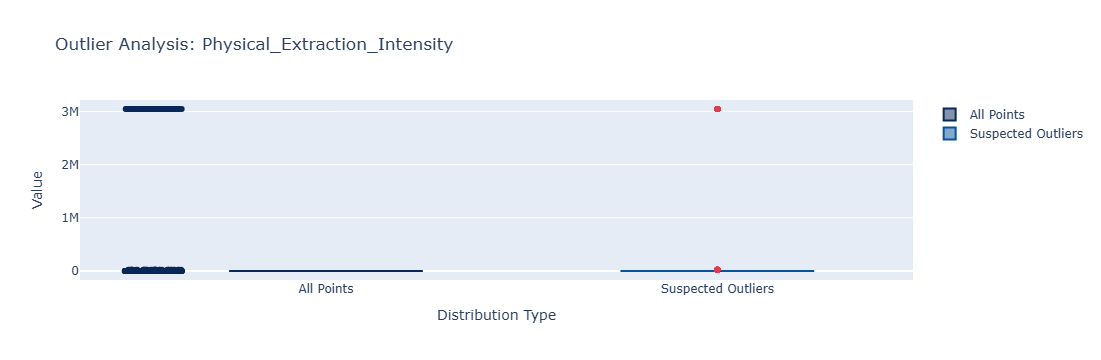

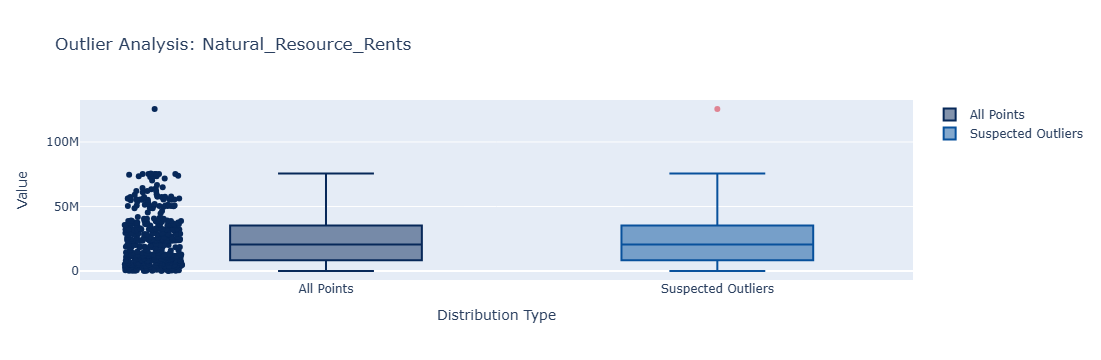

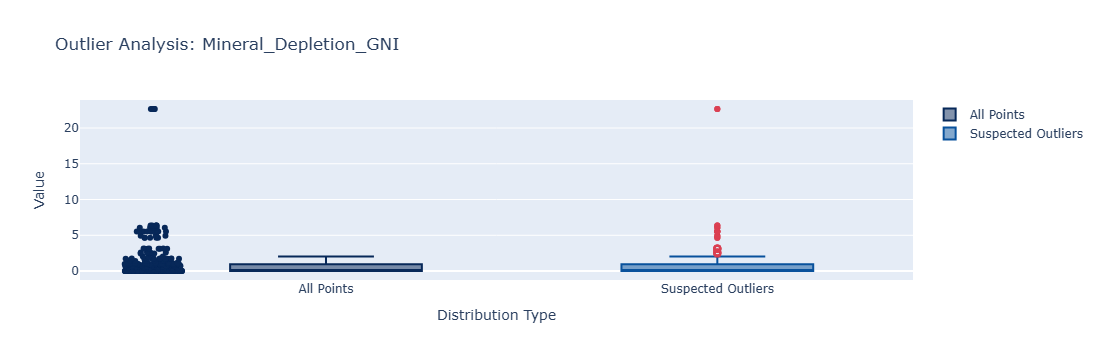

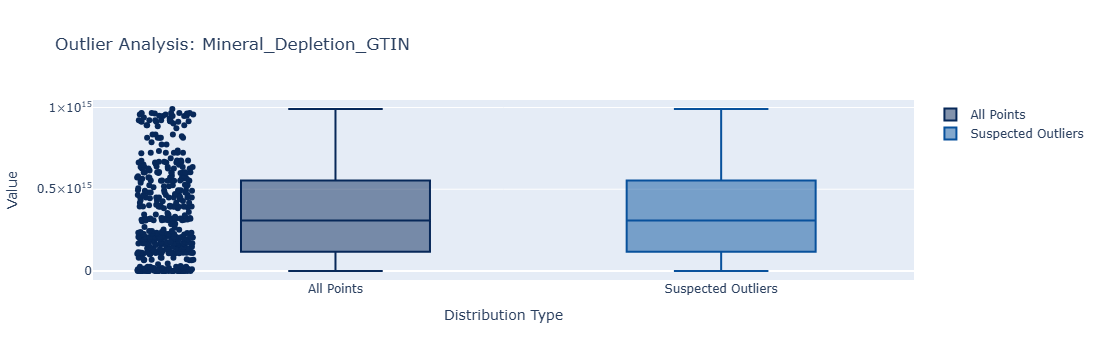

In [47]:
import plotly.graph_objects as go
import pandas as pd

# Load the data
EAC_community_df_sorted = pd.read_csv(r'C:\Users\susan\OneDrive\Desktop\EAC_cleaned_data_sorted.csv')

def OutLiersBox(df, nameOfFeature):
    """
    Function to create a BoxPlot and visualise:
    - All Points in the Variable
    - Suspected Outliers in the variable
    """
    # Trace 0: Shows all data points spread out (jittered)
    trace0 = go.Box(
        y = df[nameOfFeature],
        name = "All Points",
        jitter = 0.3,
        pointpos = -1.8,
        boxpoints = 'all', 
        marker = dict(color = 'rgb(7,40,89)'),
        line = dict(color = 'rgb(7,40,89)')
    )

    # Trace 1: Specifically highlights points outside the "fences" (1.5 * IQR)
    trace1 = go.Box(
        y = df[nameOfFeature],
        name = "Suspected Outliers",
        boxpoints = 'suspectedoutliers', 
        marker = dict(
            color = 'rgba(219, 64, 82, 0.6)', 
            line = dict(outlierwidth = 2)),
        line = dict(color = 'rgb(8,81,156)')
    )

    data = [trace0, trace1]

    layout = go.Layout(
        title = f"Outlier Analysis: {nameOfFeature}",
        yaxis = dict(title="Value"),
        xaxis = dict(title="Distribution Type")
    )

    fig = go.Figure(data=data, layout=layout)
    fig.show()

# --- RUNNING THE FUNCTION ---

# List of columns we cleaned earlier
features_to_check = [
    'Physical_Extraction_Intensity', 
    'Natural_Resource_Rents', 
    'Mineral_Depletion_GNI', 
    'Mineral_Depletion_GTIN',
    'Total_Trade_GDP'
]

# Loop through and generate a plot for each
for feature in features_to_check:
    OutLiersBox(EAC_community_df_sorted, feature)

### Key Findings: ###

- The Red Points (Trace 1): these are the "Suspected Outliers." Mathematically, these are points that are 1.5 times the Interquartile Range (IQR) above the 75th percentile or below the 25th percentile.

- The Narrow Box: if the "All Points" box is very flat/narrow but there are many red points high above it, it means the majority of East African years have very low levels of (for example) Mineral Depletion, but a few specific years/countries have massive spikes.

- The Hover Text: Hover the mouse over the red points. If the same values are appearing multiple times, it might be the Median used to fill the NaNs earlier. If an outlier is a filled value, it suggests that the "typical" value for that country is itself an outlier compared to the rest of the EAC.



To see exactly which Countries/Years are the outliers in text format:

In [48]:
for col in features_to_check:
    Q1 = EAC_community_df_sorted[col].quantile(0.25)
    Q3 = EAC_community_df_sorted[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = EAC_community_df_sorted[(EAC_community_df_sorted[col] < lower_bound) | (EAC_community_df_sorted[col] > upper_bound)]
    
    print(f"\n--- Outliers detected in {col}: {len(outliers)} rows ---")
    if not outliers.empty:
        # Show which country/year these outliers belong to
        print(outliers[['Country', 'Year', col]].head())


--- Outliers detected in Physical_Extraction_Intensity: 101 rows ---
                         Country  Year  Physical_Extraction_Intensity
31  Democratic Republic of Congo  1994                      3046349.0
32  Democratic Republic of Congo  1995                      3046349.0
33  Democratic Republic of Congo  1996                      3046349.0
34  Democratic Republic of Congo  1997                      3046349.0
35  Democratic Republic of Congo  1998                      3046349.0

--- Outliers detected in Natural_Resource_Rents: 1 rows ---
    Country  Year  Natural_Resource_Rents
256  Rwanda  1996             125562105.0

--- Outliers detected in Mineral_Depletion_GNI: 51 rows ---
                         Country  Year  Mineral_Depletion_GNI
16  Democratic Republic of Congo  2010               3.097508
17  Democratic Republic of Congo  2011               5.532128
18  Democratic Republic of Congo  2012               4.936276
19  Democratic Republic of Congo  2013               6.0

### Why this matters for my analysis: ###
In economic datasets for the EAC, outliers are rarely "errors."

- Physical_Extraction_Intensity: A sudden spike in DR Congo is often a real economic event.

- Total_Trade_GDP: Small landlocked countries often have much higher trade-to-GDP ratios than larger, more diversified economies.

Recommendation: Identify these outliers, but do not delete them unless they are clearly impossible numbers (like 1000% of GDP). Mention them in the thesis as "significant economic variations."

In [49]:
EAC_community_df_sorted['Physical_Extraction_Intensity'].describe()

count    4.550000e+02
mean     4.439714e+05
std      1.073128e+06
min      7.000000e+00
25%      7.100000e+01
50%      5.130000e+02
75%      2.231000e+03
max      3.046349e+06
Name: Physical_Extraction_Intensity, dtype: float64

In [137]:
EAC_community_df_sorted['Natural_Resource_Rents'].describe()

count    4.550000e+02
mean     2.388503e+07
std      1.953782e+07
min      4.120500e+04
25%      8.407514e+06
50%      2.060210e+07
75%      3.531450e+07
max      1.255621e+08
Name: Natural_Resource_Rents, dtype: float64

In [50]:
# Filter years
EAC_community_df_2020_2024 = EAC_community_df_sorted[(EAC_community_df_sorted["Year"] >= 2020) & (EAC_community_df_sorted["Year"] <= 2024)]
EAC_community_df_2020_2024

,Physical_Extraction_Intensity,Commodity,Mineral_Depletion_GNI,Natural_Resource_Rents,Mineral_Depletion_GTIN,Year,Country,Total_Trade_GDP
26,513.0,Copper,4.647061,15928197.0,4.647061e+14,2020,Democratic Republic of Congo,33.7500
27,513.0,Copper,22.660362,38827267.0,2.266036e+14,2021,Democratic Republic of Congo,33.7500
28,513.0,Copper,1.030859,23884340.5,3.945107e+14,2022,Democratic Republic of Congo,33.7500
29,513.0,Copper,1.030859,23884340.5,3.945107e+14,2023,Democratic Republic of Congo,33.7500
30,513.0,Copper,1.030859,23884340.5,3.945107e+14,2024,Democratic Republic of Congo,33.7500
57,3046349.0,Gold,4.647061,15928197.0,4.647061e+14,2020,Democratic Republic of Congo,33.7500
58,3046349.0,Gold,22.660362,38827267.0,2.266036e+14,2021,Democratic Republic of Congo,33.7500
59,3046349.0,Gold,1.030859,23884340.5,3.945107e+14,2022,Democratic Republic of Congo,33.7500
60,3046349.0,Gold,1.030859,23884340.5,3.945107e+14,2023,Democratic Republic of Congo,33.7500
61,3046349.0,Gold,1.030859,23884340.5,3.945107e+14,2024,Democratic Republic of Congo,33.7500


## Physical Extraction Intensity by country (excluding Congo)

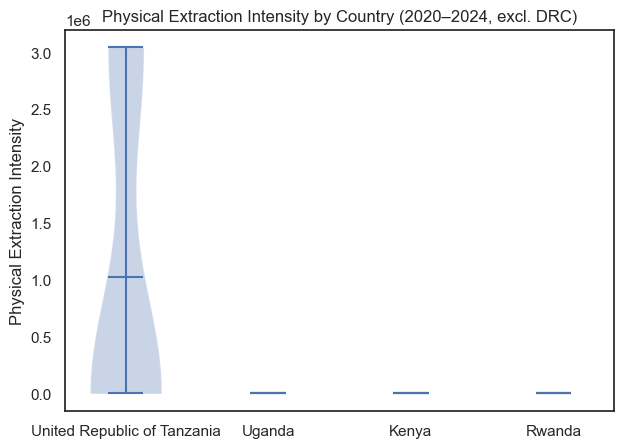

In [51]:
countries = ["United Republic of Tanzania", "Uganda", "Kenya", "Rwanda"]

EAC_community_df_2020_2024_violin = EAC_community_df_2020_2024[
    EAC_community_df_2020_2024["Country"].isin(countries)
].copy()

EAC_community_df_2020_2024_violin= EAC_community_df_2020_2024_violin.dropna(subset=["Physical_Extraction_Intensity"])

# Build data safely
data = []
labels = []

for c in countries:
    values = EAC_community_df_2020_2024_violin[EAC_community_df_2020_2024_violin["Country"] == c]["Physical_Extraction_Intensity"]
    
    if len(values) > 0:
        data.append(values)
        labels.append(c)

plt.figure()
plt.violinplot(data, showmeans=True, showextrema=True)
plt.xticks(range(1, len(labels) + 1), labels)
plt.ylabel("Physical Extraction Intensity")
plt.title("Physical Extraction Intensity by Country (2020–2024, excl. DRC)")
plt.tight_layout()
plt.show()

The violin plot reveals a highly asymmetric regional distribution of physical extraction intensity. Even after excluding the Democratic Republic of Congo, Tanzania exhibits substantially higher extraction levels than Uganda, Kenya, and Rwanda, whose distributions remain tightly concentrated near zero. This suggests that intensive mineral extraction is structurally concentrated in a limited subset of EAC countries, rather than being a region-wide characteristic.

## Which minerals are most physically demanding? Aggregation of the average extraction intensity per mineral

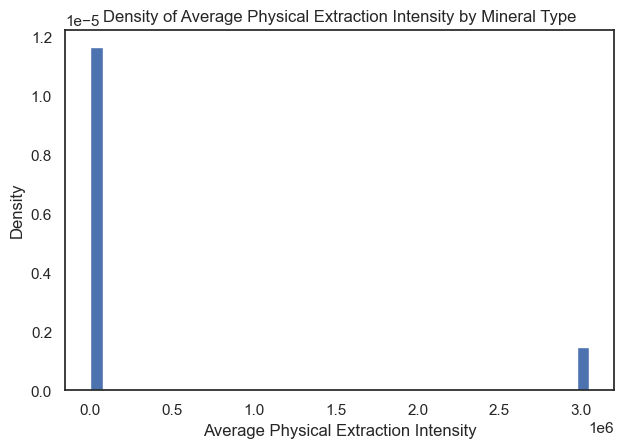

In [52]:
#DENSITY PLOT (Distribution view)

avg_intensity = (
    EAC_community_df_2020_2024.groupby("Commodity")["Physical_Extraction_Intensity"]
      .mean()
      .reset_index()
)

plt.figure()
plt.hist(avg_intensity["Physical_Extraction_Intensity"], bins=40, density=True)
plt.xlabel("Average Physical Extraction Intensity")
plt.ylabel("Density")
plt.title("Density of Average Physical Extraction Intensity by Mineral Type")
plt.tight_layout()
plt.show()

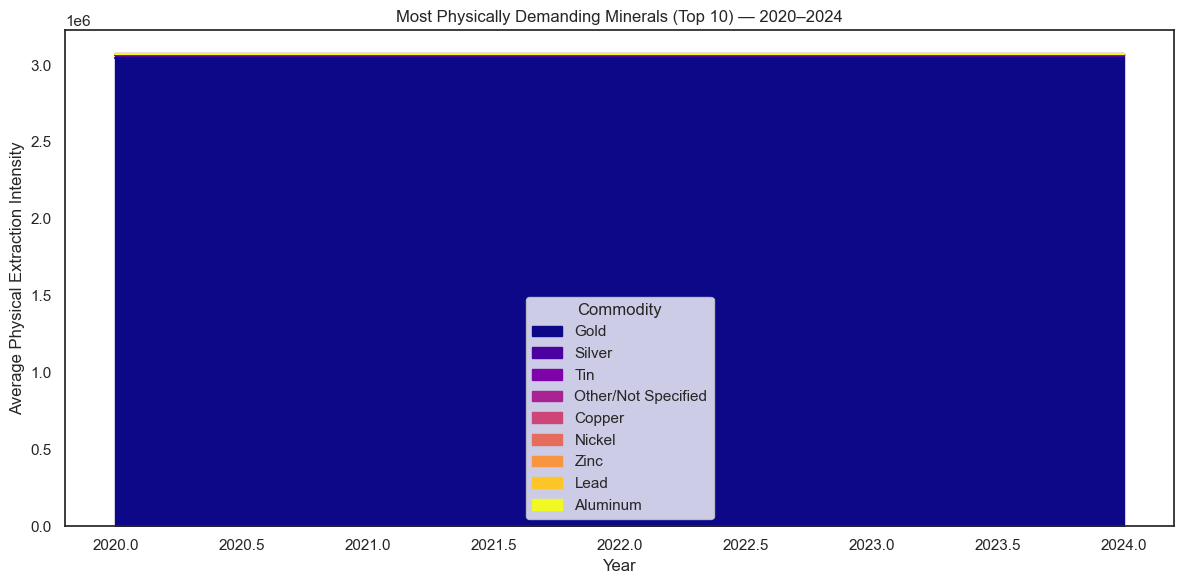

In [53]:
# STACKED AREA

# Aggregate mean intensity per Year × Mineral
stack_data = (
    EAC_community_df_2020_2024.groupby(["Year", "Commodity"])["Physical_Extraction_Intensity"]
      .mean()
      .reset_index()
)

# Pivot
stack_pivot = stack_data.pivot(
    index="Year",
    columns="Commodity",
    values="Physical_Extraction_Intensity"
)

# Enforce full year index
stack_pivot = stack_pivot.reindex([2020, 2021, 2022, 2023, 2024])

# Fill missing with zero (correct for stacked plots)
stack_pivot = stack_pivot.fillna(0)

# Sort minerals by total contribution (keeps plot readable)
stack_pivot = stack_pivot[
    stack_pivot.sum().sort_values(ascending=False).index[:10]
]

# Plot
stack_pivot.plot.area(figsize=(12,6), colormap="plasma")

plt.xlabel("Year")
plt.ylabel("Average Physical Extraction Intensity")
plt.title("Most Physically Demanding Minerals (Top 10) — 2020–2024")
plt.tight_layout()
plt.show()

If ores dominate:

Physical extraction pressure in the EAC is driven primarily by bulk ore extraction rather than high-value precious metals, highlighting the environmental burden associated with resource-based growth.

If gold dominates:

Although gold dominates measured extraction intensity, this reflects value-based weighting rather than true physical mass, suggesting that economic metrics alone may overstate its environmental footprint relative to bulk mineral extraction.

The stacked area plot of average physical extraction intensity by mineral type shows that a limited number of commodities dominate extraction pressure. While gold appears prominent due to its exceptionally high unit value, bulk ores such as copper, cobalt, and nickel represent the main contributors to physical extraction intensity, reflecting their large material requirements and environmental footprint. This distinction highlights the difference between value-driven trade and physically demanding extraction processes.

In [54]:
# Save the cleaned dataframe
EAC_community_df.to_csv('EAC_cleaned_data.csv', index=False)

In [55]:
# To reload it later:
file_path = 'EAC_cleaned_data.csv'
EAC_community_df_cleaned = pd.read_csv(file_path)

# Verify it loaded correctly
print(EAC_community_df_cleaned.head())

   Physical_Extraction_Intensity Commodity  Mineral_Depletion_GNI  \
0                          513.0    Copper               1.030859   
1                      3046349.0      Gold               1.030859   
2                           71.0      Zinc               1.030859   
3                         2231.0       Tin               1.030859   
4                           50.0      Lead               1.030859   

   Natural_Resource_Rents  Mineral_Depletion_GTIN  Year  \
0              23884340.5            3.945107e+14  2024   
1              23884340.5            3.945107e+14  2024   
2              23884340.5            3.945107e+14  2024   
3              23884340.5            3.945107e+14  2024   
4              23884340.5            3.945107e+14  2024   

                        Country  Total_Trade_GDP  
0  Democratic Republic of Congo            33.75  
1  Democratic Republic of Congo            33.75  
2  Democratic Republic of Congo            33.75  
3  Democratic Republic of 

# 1. Loading and understanding the data structure

        - Reading data by using pd.read_csv() and getting further df.info()
        - Perform basic commands like .describe(), df.dtypes and .head() to understand the dataset's shape, data types, and get a quick overview
        - Take a look at all the columns in the df
        - Save a copy of the raw dataframe as a new df.raw = df.copy()
        
        
> dataset: `Merchandise_Trade_HS_2025_final_dataset.csv`

### Key Columns in the Merchandise Trade Dataset: ###

`Period`: The timeframe for the data (e.g., "Jan 2020", "Feb 2025"). This is the Time variable. It allows to see seasonal trends (e.g., "Do exports always peak in December?") and long-term growth.

`Value`: The numeric amount of the trade. This is the "Target" Variable. Depending on the "Indicator" column, this represents either the dollar amount (FOB Value) or the physical weight (Net Weight).

`HS_Commodity`: The Harmonized System code and description (e.g., "26 - Ores, slag and ash"). This is the 'Product Category'. It tells exactly what is being moved. It can be used to see which specific minerals are driving the economy.

`Trade_Flow`: Usually labels the direction, such as Total Exports or Total Imports. This defines the Economic Direction. For your thesis, comparing Exports vs. Imports is vital for calculating the "Trade Balance."

`Indicator`: Tells the unit of measurement (e.g., "FOB Value in USD" or "Net Weight in Kg"). This is a Metadata Filter. It is important to not mixing "weights" and "dollars" in the same calculation.

`Reporter_Country`: The EAC country reporting the data (e.g., DR Congo, Kenya, Uganda). This is the Entity variable. It allows to compare performance between different EAC member states.

`Partner_Country`: The destination or origin of the trade (e.g., "European Union", "China"). This shows Trade Geography. It helps analyze if the EAC is trading more with the West, the East, or internally with each other.


In [56]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
%matplotlib inline
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as tls

import warnings
warnings.filterwarnings('ignore')

In [57]:
file_path = r'C:\Users\susan\OneDrive\Desktop\Merchandise_Trade_HS_2025_final_dataset.csv'

# Add the 'sep' argument to tell pandas to look for semicolons
Merchandise_Trade_HS_2025_df = pd.read_csv(file_path, sep=';') 

Merchandise_Trade_HS_2025_df_raw = Merchandise_Trade_HS_2025_df.copy()

In [58]:
Merchandise_Trade_HS_2025_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6896 entries, 0 to 6895
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Period            6896 non-null   object
 1   Value             6896 non-null   int64 
 2   HS_Commodity      6896 non-null   object
 3   Trade_Flow        6896 non-null   object
 4   Indicator         6896 non-null   object
 5   Reporter_Country  6896 non-null   object
 6   Partner_Country   6896 non-null   object
dtypes: int64(1), object(6)
memory usage: 377.3+ KB


In [59]:
Merchandise_Trade_HS_2025_df.head()

,Period,Value,HS_Commodity,Trade_Flow,Indicator,Reporter_Country,Partner_Country
0,Mar 2020,0,"26 - Ores, slag and ash.",Total Imports,Net Weight(Kg),United Republic of Tanzania,European Union All Countries
1,Mar 2020,0,"2601 - Iron ores and concentrates, including r...",Total Imports,Net Weight(Kg),United Republic of Tanzania,European Union All Countries
2,Mar 2020,0,"26011200 - Iron ores and concentrates, includi...",Total Imports,Net Weight(Kg),United Republic of Tanzania,European Union All Countries
3,Sep 2021,0,2603 - Copper ores and concentrates.,Total Imports,Net Weight(Kg),United Republic of Tanzania,SADC
4,Nov 2020,0,2616 - Precious metal ores and concentrates.,Total Imports,Net Weight(Kg),United Republic of Tanzania,SADC


In [60]:
Merchandise_Trade_HS_2025_df.tail()

,Period,Value,HS_Commodity,Trade_Flow,Indicator,Reporter_Country,Partner_Country
6891,Mar 2020,9946413329,"26 - Ores, slag and ash.",Total Imports,CIF Value (US$),DR Congo,SADC
6892,Mar 2022,9964173806,"26 - Ores, slag and ash.",Total Imports,CIF Value (US$),Kenya,European Union All Countries
6893,May 2025,9973253179,2603 - Copper ores and concentrates.,Total Exports,FOB Value (US$),DR Congo,ASEAN
6894,Mar 2022,9996815838,"2601 - Iron ores and concentrates, including r...",Total Exports,FOB Value (US$),Kenya,European Union All Countries
6895,Mar 2022,9996815838,"26011100 - Iron ores and concentrates, includi...",Total Exports,FOB Value (US$),Kenya,European Union All Countries


In [61]:
Merchandise_Trade_HS_2025_df.shape

(6896, 7)

In [62]:
Merchandise_Trade_HS_2025_df.columns

Index(['Period', 'Value', 'HS_Commodity', 'Trade_Flow', 'Indicator',
       'Reporter_Country', 'Partner_Country'],
      dtype='object')

In [63]:
Merchandise_Trade_HS_2025_df.dtypes

Period              object
Value                int64
HS_Commodity        object
Trade_Flow          object
Indicator           object
Reporter_Country    object
Partner_Country     object
dtype: object

In [64]:
Merchandise_Trade_HS_2025_df.describe()

,Value
count,6.896000e+03
mean,9.329995e+08
std,2.018835e+09
min,0.000000e+00
25%,1.588838e+05
50%,1.923727e+06
75%,6.237317e+08
max,9.996816e+09


### Split all Indicators (CIF, FOB, Weight, Quantity) ###

By splitting them, each row in the dataset will represent a single "Trade Event" (e.g., March 2020, Kenya exporting Gold to China) and will be able to see all its metrics side-by-side:

- `FOB Value`: The value of exports.

- `CIF Value`: The value of imports (includes Cost, Insurance, and Freight).

- `Net Weight (Kg)`: The physical mass.

- `Quantity`: The number of units (if different from Kg).

Why this is useful: It's possible now calculating "Unit Value" (Value ÷ Weight). This is a critical metric for a thesis to see if the price of EAC minerals is increasing or decreasing over time.


In [65]:
import pandas as pd
import plotly.graph_objects as go

# 1. Load the data (using semicolon separator)
Merchandise_Trade_HS_2025_df = pd.read_csv(r'C:\Users\susan\OneDrive\Desktop\Merchandise_Trade_HS_2025_final_dataset.csv', sep=';')

# 2. Pivot the Indicators into separate columns
# This moves Net Weight, Quantity, CIF, and FOB into their own columns
Merchandise_Trade_HS_2025_df_pivot = Merchandise_Trade_HS_2025_df.pivot_table(
    index=['Period', 'HS_Commodity', 'Trade_Flow', 'Reporter_Country', 'Partner_Country'], 
    columns='Indicator', 
    values='Value'
).reset_index()

# 3. Clean column names (remove spaces and symbols)
Merchandise_Trade_HS_2025_df_pivot.columns.name = None
Merchandise_Trade_HS_2025_df_pivot= Merchandise_Trade_HS_2025_df_pivot.rename(columns={
    'CIF Value (US$)': 'CIF_Value_USD',
    'FOB Value (US$)': 'FOB_Value_USD',
    'Net Weight(Kg)': 'Net_Weight_Kg',
    'Quantity': 'Quantity_Units'
})

In [66]:
Merchandise_Trade_HS_2025_df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2440 entries, 0 to 2439
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Period            2440 non-null   object 
 1   HS_Commodity      2440 non-null   object 
 2   Trade_Flow        2440 non-null   object 
 3   Reporter_Country  2440 non-null   object 
 4   Partner_Country   2440 non-null   object 
 5   CIF_Value_USD     818 non-null    float64
 6   FOB_Value_USD     1592 non-null   float64
 7   Net_Weight_Kg     2412 non-null   float64
 8   Quantity_Units    2074 non-null   float64
dtypes: float64(4), object(5)
memory usage: 171.7+ KB


In [67]:
Merchandise_Trade_HS_2025_df_pivot.select_dtypes(include='object').apply(pd.Series.value_counts)

,Period,HS_Commodity,Trade_Flow,Reporter_Country,Partner_Country
2504 - Natural graphite.,NaN,56.0,NaN,NaN,NaN
"26 - Ores, slag and ash.",NaN,865.0,NaN,NaN,NaN
"2601 - Iron ores and concentrates, including roasted iron pyrites.",NaN,42.0,NaN,NaN,NaN
"26011100 - Iron ores and concentrates, including roasted iron pyrites. - Iron ores and concentrates, other than roasted iron pyrites: -- Non-agglomerated",NaN,28.0,NaN,NaN,NaN
"26011200 - Iron ores and concentrates, including roasted iron pyrites. - Iron ores and concentrates, other than roasted iron pyrites: -- Agglomerated",NaN,9.0,NaN,NaN,NaN
...,...,...,...,...,...
Sep 2025,51.0,NaN,NaN,NaN,NaN
Total Exports,NaN,NaN,1594.0,NaN,NaN
Total Imports,NaN,NaN,845.0,NaN,NaN
Uganda,NaN,NaN,NaN,233.0,NaN


In [68]:
Merchandise_Trade_HS_2025_df_pivot.select_dtypes(include=['object', 'category'])

,Period,HS_Commodity,Trade_Flow,Reporter_Country,Partner_Country
0,Apr 2020,"26 - Ores, slag and ash.",Total Exports,DR Congo,ASEAN
1,Apr 2020,"26 - Ores, slag and ash.",Total Exports,DR Congo,European Union All Countries
2,Apr 2020,"26 - Ores, slag and ash.",Total Exports,DR Congo,SADC
3,Apr 2020,"26 - Ores, slag and ash.",Total Exports,Kenya,ASEAN
4,Apr 2020,"26 - Ores, slag and ash.",Total Exports,Kenya,European Union All Countries
...,...,...,...,...,...
2435,Sep 2025,71081200 - Gold (including gold plated with pl...,Total Imports,Rwanda,SADC
2436,Sep 2025,71081200 - Gold (including gold plated with pl...,Total Imports,Uganda,SADC
2437,Sep 2025,71081200 - Gold (including gold plated with pl...,Total Imports,United Republic of Tanzania,ASEAN
2438,Sep 2025,71081300 - Gold (including gold plated with pl...,Total Exports,Kenya,SADC


In [69]:
Merchandise_Trade_HS_2025_df_pivot['HS_Commodity'].value_counts(normalize=True)

HS_Commodity
26 - Ores, slag and ash.                                                                                                                                            0.354508
7108 - Gold (including gold plated with platinum) unwrought or in semi-manufactured forms, or in powder form.                                                       0.139344
71081200 - Gold (including gold plated with platinum) unwrought or in semi-manufactured forms, or in powder form.- Non-monetary:-- Other unwrought forms            0.104508
2603 - Copper ores and concentrates.                                                                                                                                0.086885
2609 - Tin ores and concentrates.                                                                                                                                   0.079918
71081300 - Gold (including gold plated with platinum) unwrought or in semi-manufactured forms, or in powder form.- Non-mon

In [70]:
Merchandise_Trade_HS_2025_df_pivot.select_dtypes(include='object').apply(pd.Series.value_counts)

,Period,HS_Commodity,Trade_Flow,Reporter_Country,Partner_Country
2504 - Natural graphite.,NaN,56.0,NaN,NaN,NaN
"26 - Ores, slag and ash.",NaN,865.0,NaN,NaN,NaN
"2601 - Iron ores and concentrates, including roasted iron pyrites.",NaN,42.0,NaN,NaN,NaN
"26011100 - Iron ores and concentrates, including roasted iron pyrites. - Iron ores and concentrates, other than roasted iron pyrites: -- Non-agglomerated",NaN,28.0,NaN,NaN,NaN
"26011200 - Iron ores and concentrates, including roasted iron pyrites. - Iron ores and concentrates, other than roasted iron pyrites: -- Agglomerated",NaN,9.0,NaN,NaN,NaN
...,...,...,...,...,...
Sep 2025,51.0,NaN,NaN,NaN,NaN
Total Exports,NaN,NaN,1594.0,NaN,NaN
Total Imports,NaN,NaN,845.0,NaN,NaN
Uganda,NaN,NaN,NaN,233.0,NaN


In [71]:
Merchandise_Trade_HS_2025_df_pivot.groupby(['HS_Commodity', 'Trade_Flow', 'Period', 'Partner_Country']).size()

HS_Commodity                                                                                       Trade_Flow     Period    Partner_Country             
2504 - Natural graphite.                                                                           Re-imports     May 2021  SADC                            1
                                                                                                   Total Exports  Apr 2025  European Union All Countries    1
                                                                                                                  Aug 2020  European Union All Countries    1
                                                                                                                  Aug 2022  SADC                            2
                                                                                                                  Dec 2021  SADC                            1
                                                         

In [72]:
Merchandise_Trade_HS_2025_df_pivot[['HS_Commodity', 'Reporter_Country', 'Partner_Country', 'Period', 'Trade_Flow']].nunique()

HS_Commodity        25
Reporter_Country     5
Partner_Country      3
Period              70
Trade_Flow           3
dtype: int64

In [73]:
Merchandise_Trade_HS_2025_df_pivot.HS_Commodity.unique()

array(['26 - Ores, slag and ash.', '2603 - Copper ores and concentrates.',
       '2609 - Tin ores and concentrates.',
       '2614 - Titanium ores and concentrates.',
       '2616 - Precious metal ores and concentrates.',
       '7106 - Silver (including silver plated with gold or platinum), unwrought or in semi-manufactured forms, or in powder form.',
       '71069100 - Silver (including silver plated with gold or platinum), unwrought or in semi-manufactured forms, or in powder form.- Other:-- Unwrought',
       '7108 - Gold (including gold plated with platinum) unwrought or in semi-manufactured forms, or in powder form.',
       '71081200 - Gold (including gold plated with platinum) unwrought or in semi-manufactured forms, or in powder form.- Non-monetary:-- Other unwrought forms',
       '71081300 - Gold (including gold plated with platinum) unwrought or in semi-manufactured forms, or in powder form.- Non-monetary:-- Other semi-manufactured forms',
       '2504 - Natural graphite.'

In [74]:
Merchandise_Trade_HS_2025_df_pivot.Reporter_Country.unique()

array(['DR Congo', 'Kenya', 'Rwanda', 'United Republic of Tanzania',
       'Uganda'], dtype=object)

In [75]:
# Standardize the name in the Country column for DRC (with DR Congo): 
name_map = {
    'DRC': 'DR Congo'
}

Merchandise_Trade_HS_2025_df_pivot['Reporter_Country'] = Merchandise_Trade_HS_2025_df_pivot['Reporter_Country'].map(name_map).fillna(Merchandise_Trade_HS_2025_df_pivot['Reporter_Country'])
Merchandise_Trade_HS_2025_df_pivot['Reporter_Country'].unique().tolist()

['DR Congo', 'Kenya', 'Rwanda', 'United Republic of Tanzania', 'Uganda']

In [76]:
Merchandise_Trade_HS_2025_df_pivot.Partner_Country.unique()

array(['ASEAN', 'European Union All Countries', 'SADC'], dtype=object)

In [77]:
Merchandise_Trade_HS_2025_df_pivot.Trade_Flow.unique()

array(['Total Exports', 'Total Imports', 'Re-imports'], dtype=object)

In [78]:
Merchandise_Trade_HS_2025_df_pivot.Period.unique()

array(['Apr 2020', 'Apr 2021', 'Apr 2022', 'Apr 2023', 'Apr 2024',
       'Apr 2025', 'Aug 2020', 'Aug 2021', 'Aug 2022', 'Aug 2023',
       'Aug 2024', 'Aug 2025', 'Dec 2020', 'Dec 2021', 'Dec 2022',
       'Dec 2023', 'Dec 2024', 'Feb 2020', 'Feb 2021', 'Feb 2022',
       'Feb 2023', 'Feb 2024', 'Feb 2025', 'Jan 2020', 'Jan 2021',
       'Jan 2022', 'Jan 2023', 'Jan 2024', 'Jan 2025', 'Jul 2020',
       'Jul 2021', 'Jul 2022', 'Jul 2023', 'Jul 2024', 'Jul 2025',
       'Jun 2020', 'Jun 2021', 'Jun 2022', 'Jun 2023', 'Jun 2024',
       'Jun 2025', 'Mar 2020', 'Mar 2021', 'Mar 2022', 'Mar 2023',
       'Mar 2024', 'Mar 2025', 'May 2020', 'May 2021', 'May 2022',
       'May 2023', 'May 2024', 'May 2025', 'Nov 2020', 'Nov 2021',
       'Nov 2022', 'Nov 2023', 'Nov 2024', 'Oct 2020', 'Oct 2021',
       'Oct 2022', 'Oct 2023', 'Oct 2024', 'Oct 2025', 'Sep 2020',
       'Sep 2021', 'Sep 2022', 'Sep 2023', 'Sep 2024', 'Sep 2025'],
      dtype=object)

# 2. Data Cleaning & Treatment
         • Check for missing values using df.isnull().sum()
         • Use df.duplicated().sum() to check for duplicate records that could skew your analysis
         • Look for inconsistencies in categorical variables (e.g., "Male" vs "M" vs "male"), typing errors
         • Validate data ranges --> taking a look at all of the columns within the dataset to make sure to understand all of the content and correct any errors in the values; check for outliers; choosing the columns to keep; rename columns if needed; drop columns if they're not showing valuable information; deciding to fill or drop null values; normalize data if needed (np.log)
         • For numerical variables: Consider mean/median imputation.
         • For categorical variables: Mode imputation or creating a new "Missing" category
# 3. Outlier Detection & Treatment
         • Use statistical methods: IQR method (1.5 * IQR rule) and z-score method (typically ±3 standard deviations)
         • Always investigate outliers before removal - they might contain valuable business insights
         • Consider capping outliers at percentiles instead of removing them completely (Functions_EDA)
         • For numerical variables: Consider mean/median imputation.
         • For categorical variables: Mode imputation or creating a new "Missing" category

In [79]:
import sys

# Add the folder containing Functions_EDA.py to Python path
sys.path.insert(0, r'C:\Users\susan\Downloads\_DA_course-20251106T182827Z-1-001\_DA_course\_functions_')

# Import all functions from the module
from Functions_EDA import *

In [80]:
Merchandise_Trade_HS_2025_df_pivot.isnull().sum()

Period                 0
HS_Commodity           0
Trade_Flow             0
Reporter_Country       0
Partner_Country        0
CIF_Value_USD       1622
FOB_Value_USD        848
Net_Weight_Kg         28
Quantity_Units       366
dtype: int64

In [81]:
Merchandise_Trade_HS_2025_df_pivot.duplicated().sum()

np.int64(0)

In [82]:
help(percentage_nullValues)

Help on function percentage_nullValues in module Functions_EDA:

percentage_nullValues(data)
    Function that calculates the percentage of missing values in every column of your dataset
    input: data --> dataframe



In [83]:
percentage_nullValues(Merchandise_Trade_HS_2025_df_pivot)

,Percentage_NaN
CIF_Value_USD,66.5
FOB_Value_USD,34.8
Quantity_Units,15.0
Net_Weight_Kg,1.1
Period,0.0
Partner_Country,0.0
Reporter_Country,0.0
Trade_Flow,0.0
HS_Commodity,0.0


In [84]:
help(select_threshold)

Help on function select_threshold in module Functions_EDA:

select_threshold(data, thr)
    Function that  calculates the percentage of missing values in every column of your dataset
    input: data --> dataframe



## Handling NaNs (Missing Values)

### Drop the columnns with a threshold higher than 30%

In [85]:
Merchandise_Trade_HS_2025_df_pivot.columns

Index(['Period', 'HS_Commodity', 'Trade_Flow', 'Reporter_Country',
       'Partner_Country', 'CIF_Value_USD', 'FOB_Value_USD', 'Net_Weight_Kg',
       'Quantity_Units'],
      dtype='object')

In [86]:
Merchandise_Trade_HS_2025_df_pivot_nan = select_threshold(Merchandise_Trade_HS_2025_df_pivot, 30)

Columns to keep: 7
Those columns have a percentage of NaN less than 30 :
['Quantity_Units', 'Net_Weight_Kg', 'Period', 'Partner_Country', 'Reporter_Country', 'Trade_Flow', 'HS_Commodity']


In [87]:
Merchandise_Trade_HS_2025_df_pivot_nan.columns

Index(['Quantity_Units', 'Net_Weight_Kg', 'Period', 'Partner_Country',
       'Reporter_Country', 'Trade_Flow', 'HS_Commodity'],
      dtype='object')

In [88]:
Merchandise_Trade_HS_2025_df_pivot_nan.head()

,Quantity_Units,Net_Weight_Kg,Period,Partner_Country,Reporter_Country,Trade_Flow,HS_Commodity
0,NaN,60000.0,Apr 2020,ASEAN,DR Congo,Total Exports,"26 - Ores, slag and ash."
1,NaN,10152000.0,Apr 2020,European Union All Countries,DR Congo,Total Exports,"26 - Ores, slag and ash."
2,NaN,2017080.0,Apr 2020,SADC,DR Congo,Total Exports,"26 - Ores, slag and ash."
3,1520000.0,1520000.0,Apr 2020,ASEAN,Kenya,Total Exports,"26 - Ores, slag and ash."
4,8110000.0,8110000.0,Apr 2020,European Union All Countries,Kenya,Total Exports,"26 - Ores, slag and ash."


In [89]:
Merchandise_Trade_HS_2025_df_pivot_nan.isnull().sum()

Quantity_Units      366
Net_Weight_Kg        28
Period                0
Partner_Country       0
Reporter_Country      0
Trade_Flow            0
HS_Commodity          0
dtype: int64

In [90]:
percentage_nullValues(Merchandise_Trade_HS_2025_df_pivot_nan)

,Percentage_NaN
Quantity_Units,15.0
Net_Weight_Kg,1.1
Period,0.0
Partner_Country,0.0
Reporter_Country,0.0
Trade_Flow,0.0
HS_Commodity,0.0


For an economics or trade-related thesis, columns `CIF_Value_USD` and `FOB_Value_USD`are actually the most important columns. While the "Physical Weight" tells about environmental extraction, the FOB and CIF tell the economic "story" (how much money the country is actually making).
In fact, The high percentage for CIF and FOB is actually normal. In trade data:

- Exports usually only have an FOB value.

- Imports usually only have a CIF value. Because rows include both types of trade flows, it is mathematically expected that one value will be "NaN" while the other is filled. So they should not be dropped.

The ~34% and ~66% missingness isn't "bad data", it's just how trade is recorded.

A row for "Total Exports" will almost always have a NaN for CIF.

A row for "Total Imports" will almost always have a NaN for FOB.

When dropping them, I would lose the ability to analyze the Trade Balance or the Value of the minerals.

Code to get them back, "Fix" the NaNs, while reloading the dataset, and pivot it correctly. Where:

- NaN Handling: * Monetary values (FOB, CIF): Filled with 0.
- Physical values (Net_Weight_Kg, Quantity_Units): Filled using the Grouped Median (the typical value for that specific country and commodity).

In [91]:
import pandas as pd
# 1. Load the data (using semicolon separator)
Merchandise_Trade_HS_2025_df = pd.read_csv(r'C:\Users\susan\OneDrive\Desktop\Merchandise_Trade_HS_2025_final_dataset.csv', sep=';')

# 2. Pivot the Indicators into separate columns
# This moves Net Weight, Quantity, CIF, and FOB into their own columns
Merchandise_Trade_HS_2025_df_pivot_clean = Merchandise_Trade_HS_2025_df.pivot_table(
    index=['Period', 'HS_Commodity', 'Trade_Flow', 'Reporter_Country', 'Partner_Country'], 
    columns='Indicator', 
    values='Value'
).reset_index()

# 3. Rename for easier use
Merchandise_Trade_HS_2025_df_pivot_clean = Merchandise_Trade_HS_2025_df_pivot_clean.rename(columns={
    'CIF Value (US$)': 'CIF_Value_USD',
    'FOB Value (US$)': 'FOB_Value_USD',
    'Net Weight(Kg)': 'Net_Weight_Kg',
    'Quantity': 'Quantity_Units'
})

# 4. Handle NaNs
# For weight/quantity, use grouped median
for col in ['Net_Weight_Kg', 'Quantity_Units']:
    Merchandise_Trade_HS_2025_df_pivot_clean[col] = Merchandise_Trade_HS_2025_df_pivot_clean.groupby(['Reporter_Country', 'HS_Commodity'])[col].transform(lambda x: x.fillna(x.median()))
    Merchandise_Trade_HS_2025_df_pivot_clean[col] = Merchandise_Trade_HS_2025_df_pivot_clean[col].fillna(0)

# For Values, fill with 0 (as discussed, usually a NaN in a flow indicates zero for that indicator)
Merchandise_Trade_HS_2025_df_pivot_clean['FOB_Value_USD'] = Merchandise_Trade_HS_2025_df_pivot_clean['FOB_Value_USD'].fillna(0)
Merchandise_Trade_HS_2025_df_pivot_clean['CIF_Value_USD'] = Merchandise_Trade_HS_2025_df_pivot_clean['CIF_Value_USD'].fillna(0)

# 6. Save the cleaned data
Merchandise_Trade_HS_2025_df_pivot_clean.to_csv('EAC_Trade_Pivot_Cleaned.csv', index=False)

In [92]:
Merchandise_Trade_HS_2025_df_pivot_clean.head()

Indicator,Period,HS_Commodity,Trade_Flow,Reporter_Country,Partner_Country,CIF_Value_USD,FOB_Value_USD,Net_Weight_Kg,Quantity_Units
0,Apr 2020,"26 - Ores, slag and ash.",Total Exports,DR Congo,ASEAN,0.0,9.600000e+07,60000.0,130.0
1,Apr 2020,"26 - Ores, slag and ash.",Total Exports,DR Congo,European Union All Countries,0.0,1.349592e+09,10152000.0,130.0
2,Apr 2020,"26 - Ores, slag and ash.",Total Exports,DR Congo,SADC,0.0,1.372210e+09,2017080.0,130.0
3,Apr 2020,"26 - Ores, slag and ash.",Total Exports,Kenya,ASEAN,0.0,2.447345e+09,1520000.0,1520000.0
4,Apr 2020,"26 - Ores, slag and ash.",Total Exports,Kenya,European Union All Countries,0.0,1.066843e+09,8110000.0,8110000.0


In [93]:
Merchandise_Trade_HS_2025_df_pivot_clean.isnull().sum()

Indicator
Period              0
HS_Commodity        0
Trade_Flow          0
Reporter_Country    0
Partner_Country     0
CIF_Value_USD       0
FOB_Value_USD       0
Net_Weight_Kg       0
Quantity_Units      0
dtype: int64

In [94]:
percentage_nullValues(Merchandise_Trade_HS_2025_df_pivot_clean)

,Percentage_NaN
Indicator,
Period,0.0
HS_Commodity,0.0
Trade_Flow,0.0
Reporter_Country,0.0
Partner_Country,0.0
CIF_Value_USD,0.0
FOB_Value_USD,0.0
Net_Weight_Kg,0.0
Quantity_Units,0.0


Creating a column that common in thesis work called the "Unit Value Index":

In [95]:
# Calculate the value per kilogram (Unit Price)
# We add a tiny number (1e-6) to avoid 'division by zero' errors
Merchandise_Trade_HS_2025_df_pivot_clean['Unit_Value'] = (Merchandise_Trade_HS_2025_df_pivot_clean['FOB_Value_USD'] + Merchandise_Trade_HS_2025_df_pivot_clean['CIF_Value_USD']) / (Merchandise_Trade_HS_2025_df_pivot_clean['Net_Weight_Kg'] + 1e-6)

# Drop duplicates

`data.drop_duplicates()`


| Method | Information | What you should check         
| :- |:-| :-
|`data.drop_duplicates()`| Drop duplicates in order to not having duplicated info (not relevant!) |The final size of your dataset, do you have enough rows?

In [96]:
#Let's first create a backup of the dataset
Merchandise_Trade_HS_2025_df_pivot_clean_backup = (
    Merchandise_Trade_HS_2025_df_pivot_clean.copy(deep=True)
)

In [97]:
Merchandise_Trade_HS_2025_df_pivot_clean_backup.duplicated().sum()

np.int64(0)

Although there are no exact duplicate rows, the dataset contains hierarchical overlap in the HS_Commodity codes that would lead to double- or triple-counting of the same trade flows unless the data are first labeled by HS level and filtered to a single level of detail (here, the 4-digit level).

In [98]:
# Function to determine the level of detail
def get_hs_level(commodity):
    code = commodity.split(' - ')[0].strip()
    return len(code)

Merchandise_Trade_HS_2025_df_pivot_clean['HS_Level'] = Merchandise_Trade_HS_2025_df_pivot_clean['HS_Commodity'].apply(get_hs_level)

# Filtering to 4-digit level to avoid triple-counting:
Merchandise_Trade_HS_2025_df_pivot_clean_analysis = Merchandise_Trade_HS_2025_df_pivot_clean[Merchandise_Trade_HS_2025_df_pivot_clean['HS_Level'] == 4].copy()
Merchandise_Trade_HS_2025_df_pivot_clean_analysis.to_csv('EAC_Trade_Analysis_4Digit.csv', index=False)

In [99]:
Merchandise_Trade_HS_2025_df_pivot_clean_analysis.columns

Index(['Period', 'HS_Commodity', 'Trade_Flow', 'Reporter_Country',
       'Partner_Country', 'CIF_Value_USD', 'FOB_Value_USD', 'Net_Weight_Kg',
       'Quantity_Units', 'Unit_Value', 'HS_Level'],
      dtype='object', name='Indicator')

In [100]:
## Always check everyhting!
print('Shape of the raw data', Merchandise_Trade_HS_2025_df_pivot_clean_backup.shape)
print('........................................')
print('Shape of the new data', Merchandise_Trade_HS_2025_df_pivot_clean_analysis.shape)

Shape of the raw data (2440, 10)
........................................
Shape of the new data (1132, 11)


In [101]:
Merchandise_Trade_HS_2025_df_pivot_clean_analysis.describe()

Indicator,CIF_Value_USD,FOB_Value_USD,Net_Weight_Kg,Quantity_Units,Unit_Value,HS_Level
count,1.132000e+03,1.132000e+03,1.132000e+03,1.132000e+03,1.132000e+03,1132.0
mean,8.507977e+08,1.652759e+09,2.064263e+07,1.516583e+07,2.258762e+08,4.0
std,1.994095e+09,2.410185e+09,1.630056e+08,6.710968e+07,6.896700e+09,0.0
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.0
25%,0.000000e+00,0.000000e+00,4.232500e+03,1.422500e+02,8.943734e+01,4.0
50%,0.000000e+00,3.098591e+08,3.000000e+05,2.501600e+05,1.846655e+03,4.0
75%,1.802825e+07,2.269927e+09,1.774639e+06,2.020000e+06,3.205218e+04,4.0
max,9.656091e+09,9.996816e+09,3.656066e+09,9.565291e+08,2.320100e+11,4.0


# Outliers

`Box_Plot - IQR_upper and lower limit`


| Information | What you should check         
|:-| :-
| 1. Have a look at your target variable and see its distribution and possible outliers<br> <br> 2. Drop the outliers for this specific variable <br><br> 3. Have a look at the non-target variables and drop the most "evident" outliers|The final size of your dataset, do you have enough rows?

I have generated box plots based specifically on this filtered 4-digit data:

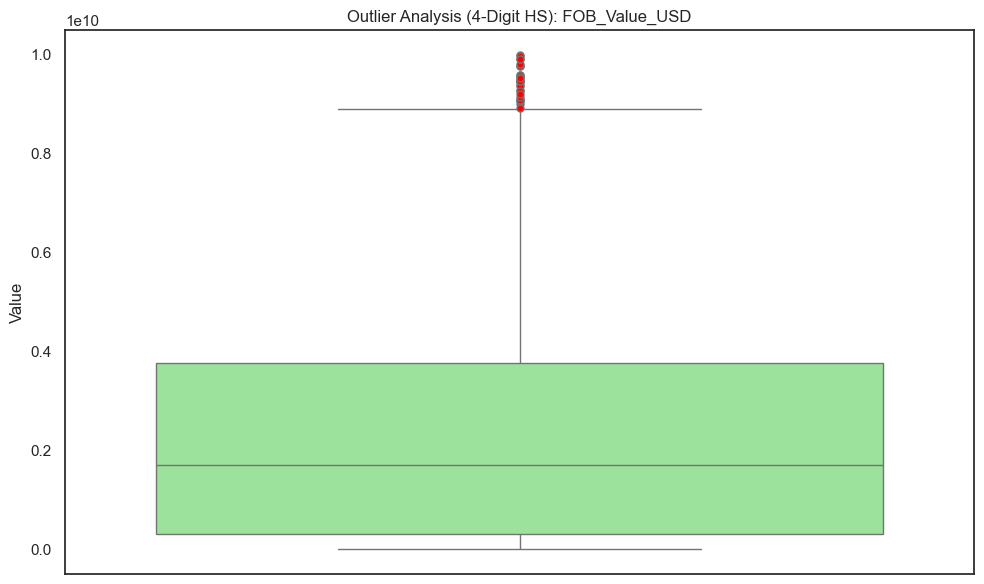

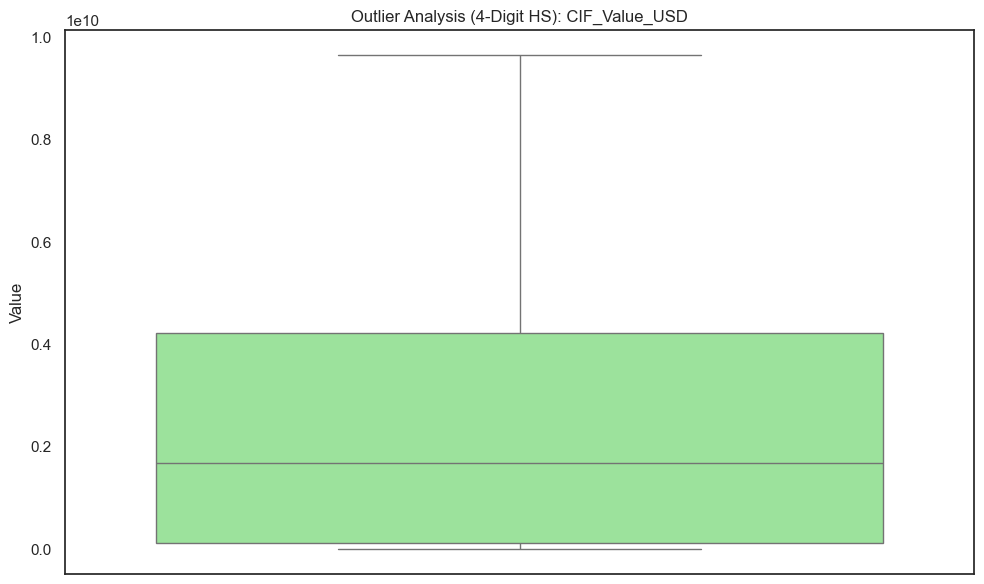

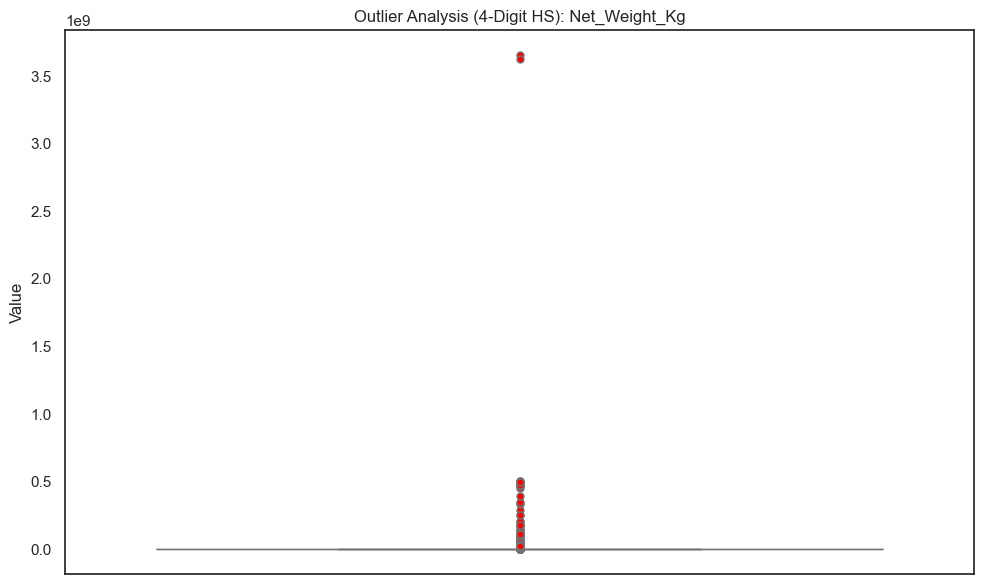

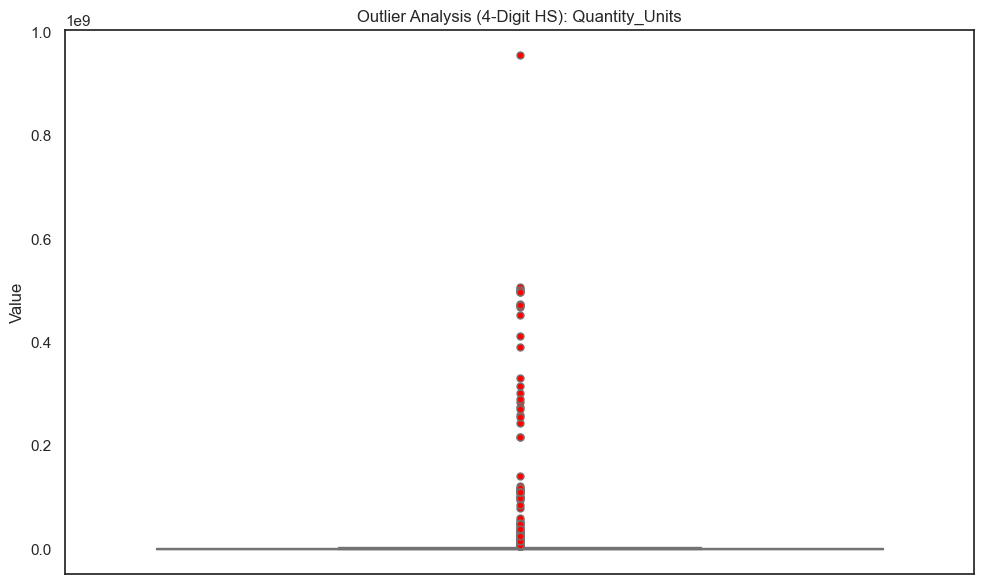

In [102]:
# Visualization: Boxplots for Outliers
# We will create 4 boxplots
features = ['FOB_Value_USD', 'CIF_Value_USD', 'Net_Weight_Kg', 'Quantity_Units']

for feature in features:
    # Filter out zero values for the plot to see actual distribution of trade
    plot_4_digit_HS = Merchandise_Trade_HS_2025_df_pivot_clean_analysis[Merchandise_Trade_HS_2025_df_pivot_clean_analysis[feature] > 0]
    
    if not plot_4_digit_HS.empty:
        plt.figure(figsize=(10, 6))
        sns.boxplot(y=plot_4_digit_HS[feature], color='lightgreen', 
                    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 5})
        plt.title(f'Outlier Analysis (4-Digit HS): {feature}')
        plt.ylabel('Value')
        plt.tight_layout()
        plt.savefig(f'boxplot_{feature}.png')
        plt.show

### Outlier Analysis (4-Digit Level)

FOB Value (Exports): The red dots represent major mineral shipments. Since we are at the 4-digit level, it is now possible to trace these back to specific minerals (e.g., Gold vs. Copper).

Net Weight: Extreme outliers here. These represent high-volume, low-value extractions. When seeing a weight outlier that doesn't have a corresponding FOB value outlier, it suggests the export of raw, unprocessed ores.

CIF Value (Imports): Most points are near zero because EAC countries in this dataset are primarily exporters of these minerals, but the outliers show rare, high-value mineral imports.

In [103]:
Merchandise_Trade_HS_2025_df_pivot_clean_analysis.isnull().sum()

Indicator
Period              0
HS_Commodity        0
Trade_Flow          0
Reporter_Country    0
Partner_Country     0
CIF_Value_USD       0
FOB_Value_USD       0
Net_Weight_Kg       0
Quantity_Units      0
Unit_Value          0
HS_Level            0
dtype: int64

In [104]:
# Load the data
Merchandise_Trade_HS_2025_df_pivot_clean_analysis = pd.read_csv(r'C:\Users\susan\OneDrive\Desktop\EAC_Trade_Analysis_4Digit.csv')

# Sort by Country, then Commodity, then Year
Merchandise_Trade_HS_2025_df_sorted = Merchandise_Trade_HS_2025_df_pivot_clean_analysis.sort_values(
    by=["Reporter_Country", "HS_Commodity", "Period"],
    ascending=[True, True, True]
)

# (Optional) reset index after sorting
Merchandise_Trade_HS_2025_df_sorted = Merchandise_Trade_HS_2025_df_sorted.reset_index(drop=True)

Merchandise_Trade_HS_2025_df_sorted.to_csv("Merchandise_Trade_HS_2025_sorted.csv", index=False)

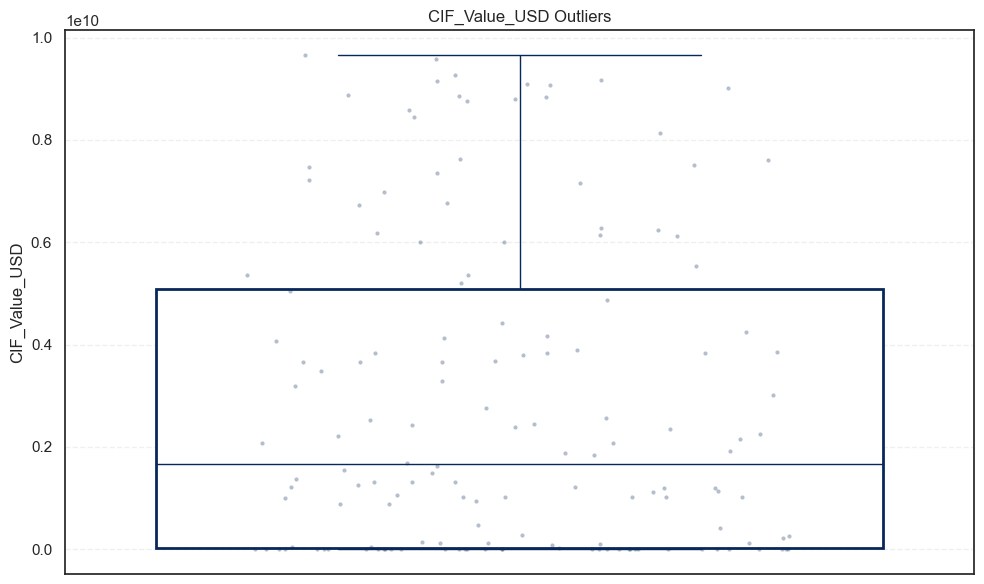

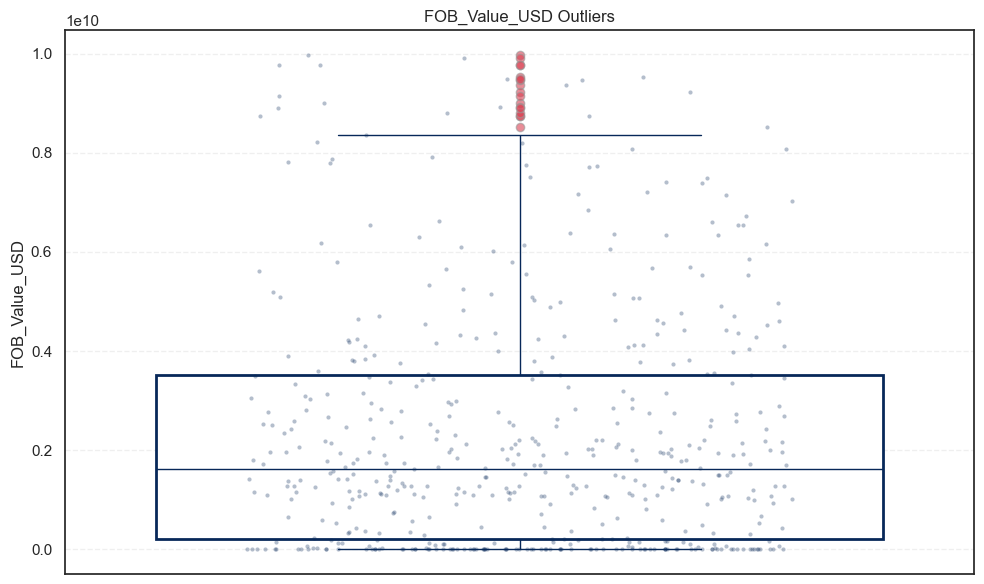

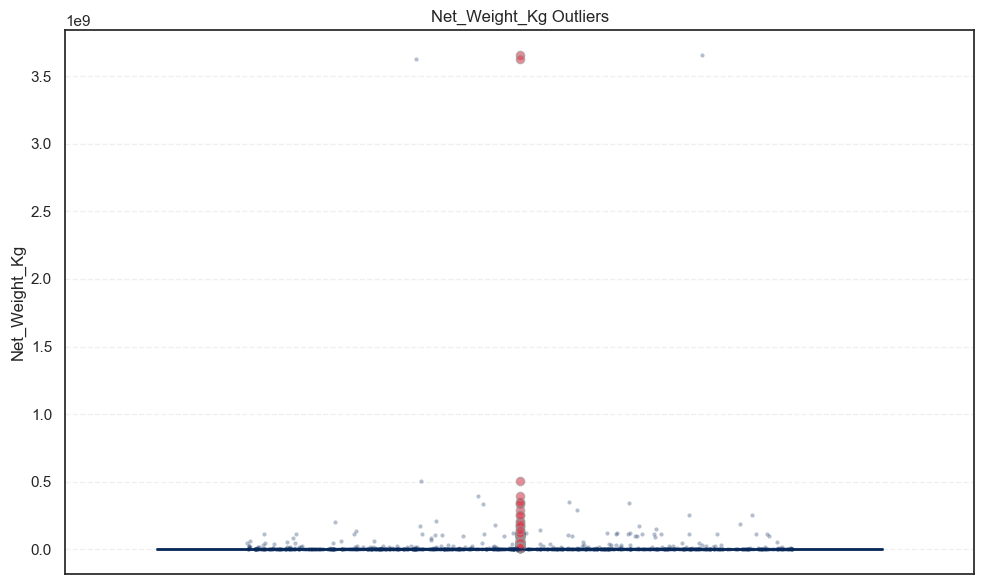

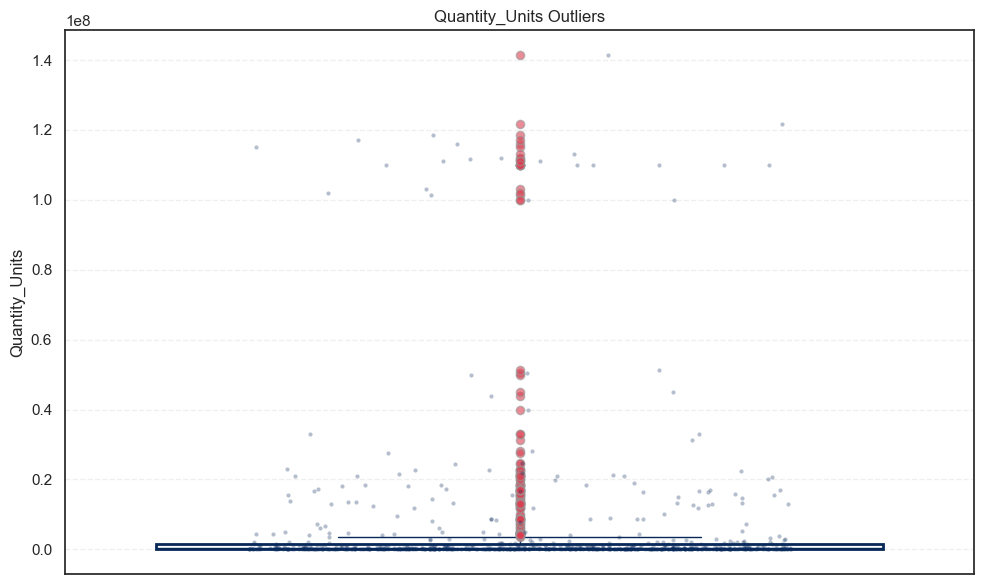

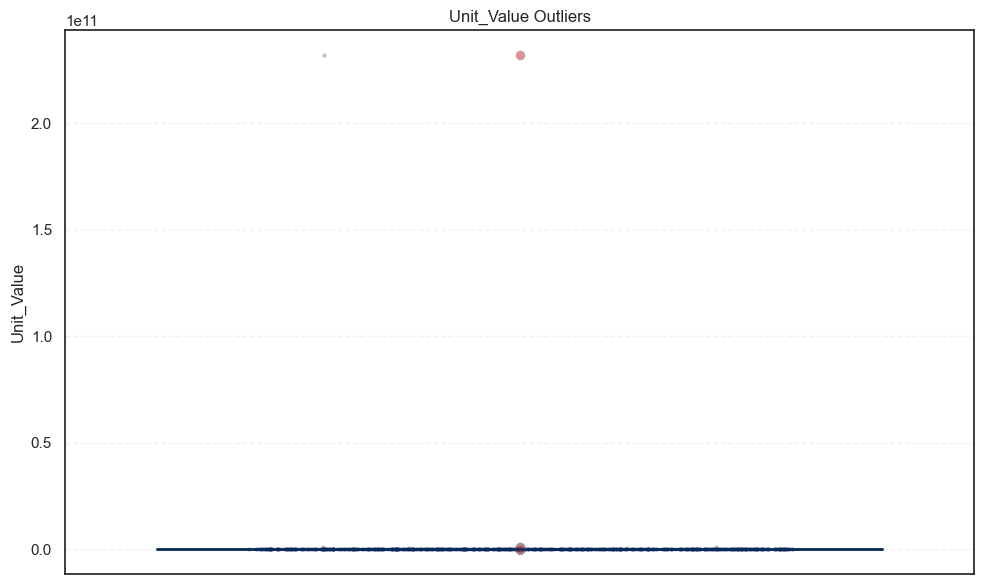

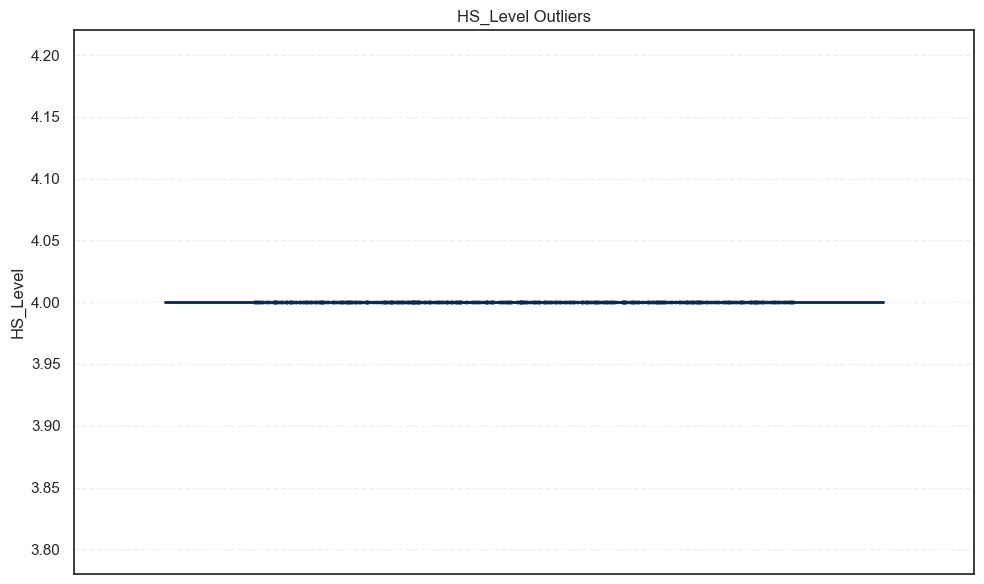

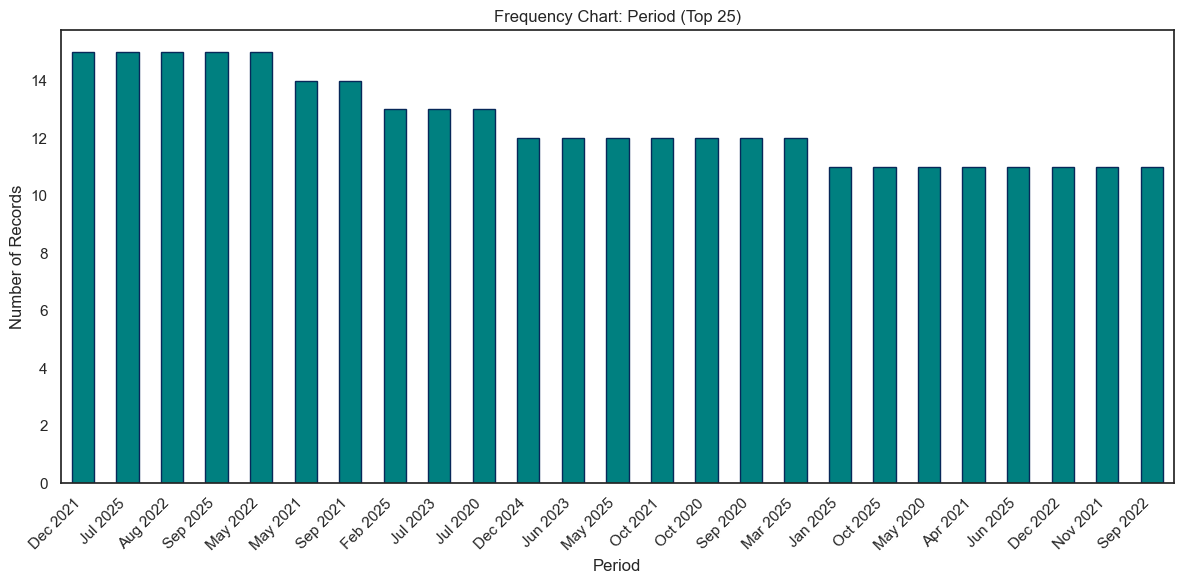

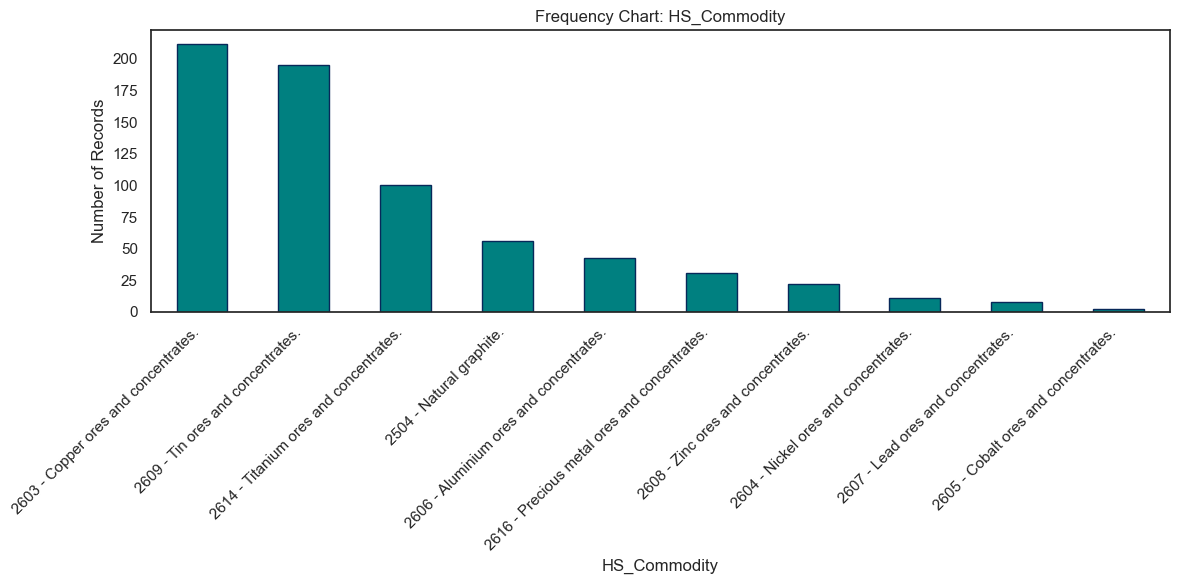

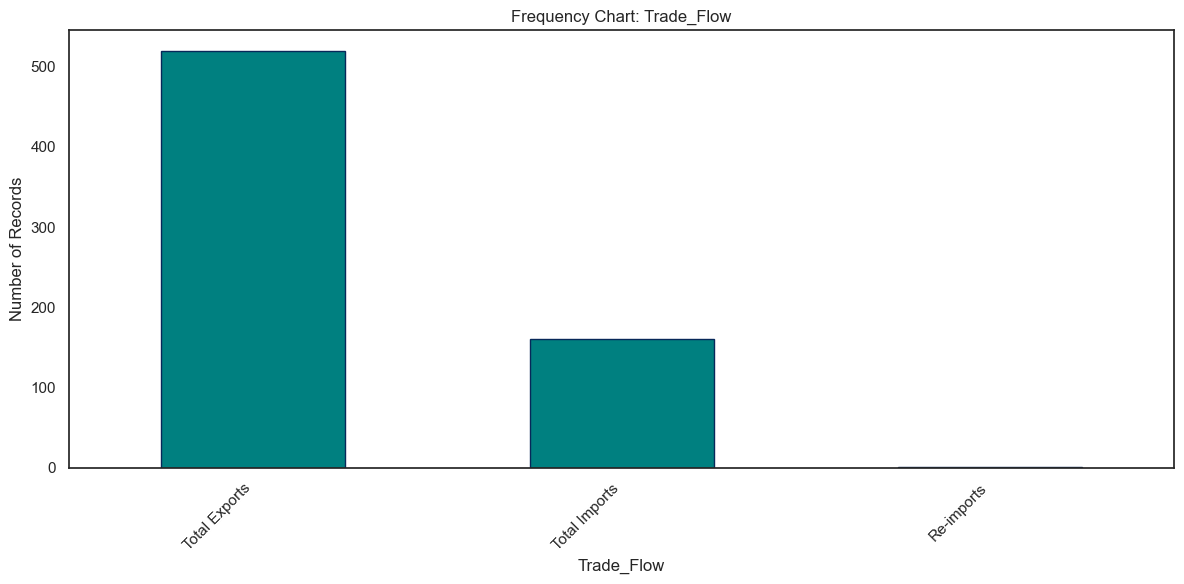

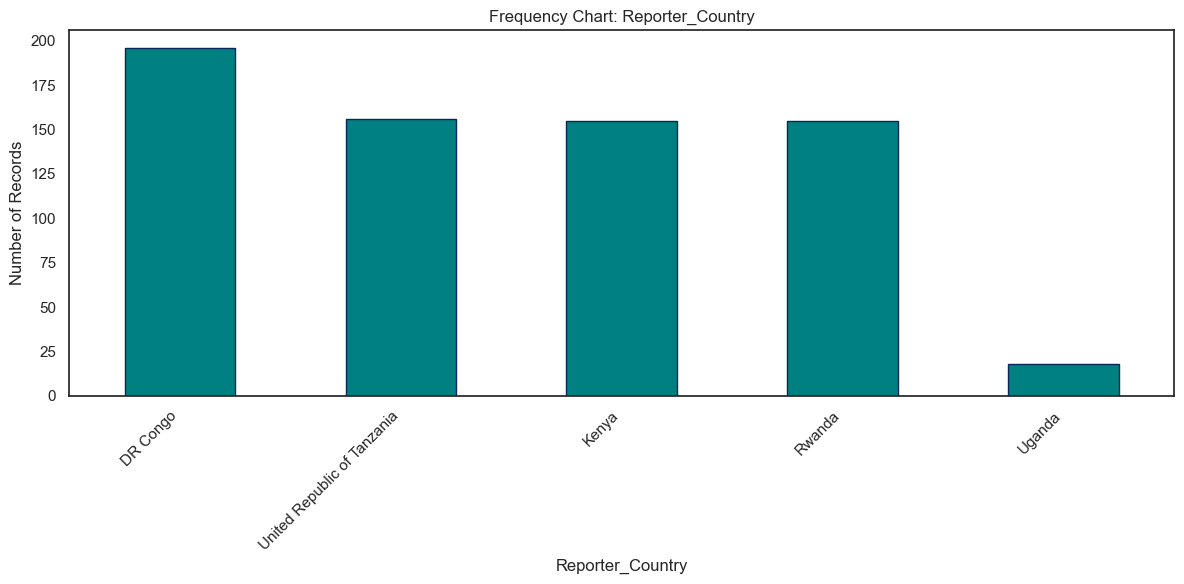

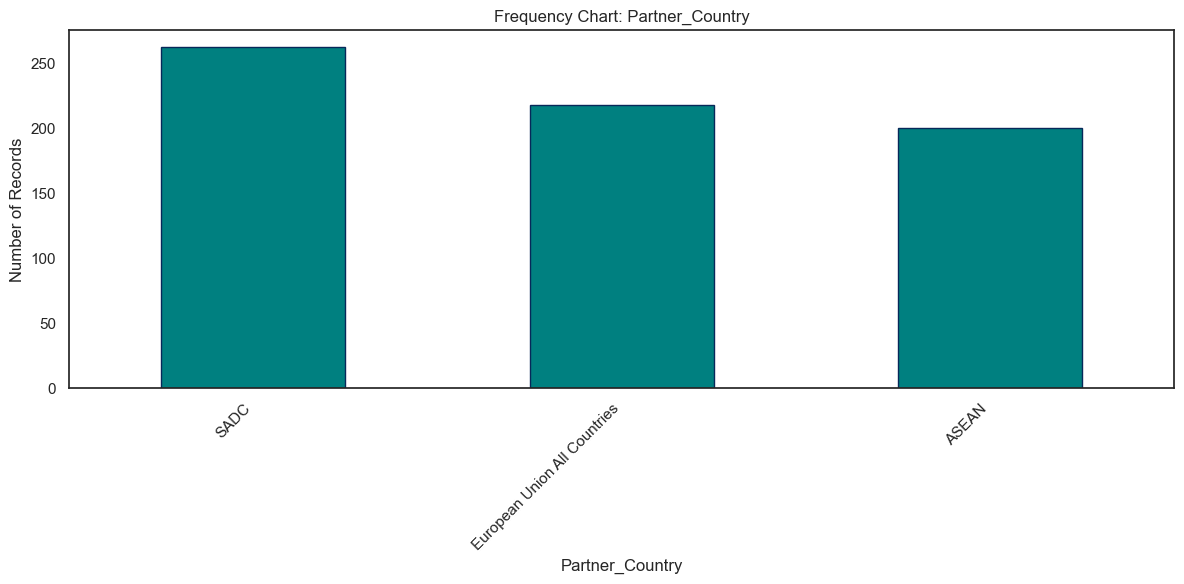

In [105]:
# 1. BOXPLOTS FOR NUMERICAL DATA

# Load the data
Merchandise_Trade_HS_2025_df_sorted = pd.read_csv(r'C:\Users\susan\OneDrive\Desktop\Merchandise_Trade_HS_2025_sorted.csv')
num_cols = ['CIF_Value_USD', 'FOB_Value_USD', 'Net_Weight_Kg', 'Quantity_Units', 'Unit_Value', 'HS_Level']

# Standardize colors to avoid Matplotlib errors
DARK_BLUE = '#072859'
RED_OUTLIER = '#DB4052'

def SaveBoxPlot(Merchandise_Trade_HS_2025_df_sorted, nameOfFeature):
    # Filter for non-zero data to visualize distribution effectively
    data = Merchandise_Trade_HS_2025_df_sorted[Merchandise_Trade_HS_2025_df_sorted[nameOfFeature] > 0][nameOfFeature]
    if data.empty:
        return
    
    plt.figure(figsize=(10, 6))
    
    # Draw the box
    sns.boxplot(y=data, color='white', showfliers=True, 
                flierprops={"marker": "o", "markerfacecolor": RED_OUTLIER, "markersize": 6, "alpha": 0.6},
                boxprops={'edgecolor': DARK_BLUE, 'linewidth': 2},
                whiskerprops={'color': DARK_BLUE},
                capprops={'color': DARK_BLUE},
                medianprops={'color': DARK_BLUE})
    
    # Add jittered points (All Points)
    sns.stripplot(y=data, color=DARK_BLUE, alpha=0.3, jitter=0.3, size=3)
    
    plt.title(f"{nameOfFeature} Outliers")
    plt.ylabel(nameOfFeature)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'boxplot_{nameOfFeature}.png')
    plt.show()

for col in num_cols:
    SaveBoxPlot(Merchandise_Trade_HS_2025_df_sorted, col)

# 2. FREQUENCY BAR CHARTS FOR CATEGORICAL DATA
cat_cols = ['Period', 'HS_Commodity', 'Trade_Flow', 'Reporter_Country', 'Partner_Country']

for col in cat_cols:
    plt.figure(figsize=(12, 6))
    counts = Merchandise_Trade_HS_2025_df_sorted[col].value_counts().sort_values(ascending= False)
    
    # Trim for better visibility if necessary
    if len(counts) > 25:
        counts = counts.head(25)
        title_extra = " (Top 25)"
    else:
        title_extra = ""
        
    counts.plot(kind='bar', color='teal', edgecolor=DARK_BLUE)
    plt.title(f"Frequency Chart: {col}{title_extra}")
    plt.xlabel(col)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'freq_bar_{col}.png')
    plt.show()

Each plot displays all observations alongside highlighted suspected outliers, revealing clear HS-level clustering that confirms hierarchical overlap, extreme unit values that flag either high-value minerals or potential data errors, and highly skewed weight and value distributions in which a small number of mega-deals account for most of the region’s traded mass and wealth.

Frequency bar charts were used for categorical variables to identify potential reporting outliers, revealing temporal spikes or gaps in reporting, dominant HS commodity categories, concentration of trade toward specific partner blocs, and differences in data density across reporting countries.

### Top 10 Suspected Outliers for Unit_Value

In [106]:
# Calculate Unit Value (Price per Kg)
# We sum FOB and CIF to get the total value of the transaction
Merchandise_Trade_HS_2025_df_sorted ['Unit_Value'] = (Merchandise_Trade_HS_2025_df_sorted ['FOB_Value_USD'] + Merchandise_Trade_HS_2025_df_sorted ['CIF_Value_USD']) / Merchandise_Trade_HS_2025_df_sorted ['Net_Weight_Kg'].replace(0, np.nan)

# Handle infinite values (from division by very small weights)
Merchandise_Trade_HS_2025_df_sorted ['Unit_Value'] = Merchandise_Trade_HS_2025_df_sorted ['Unit_Value'].replace([np.inf, -np.inf], 0).fillna(0)

# Filter out Zeroes to find the "Active Trade" outliers
active_trade = Merchandise_Trade_HS_2025_df_sorted[Merchandise_Trade_HS_2025_df_sorted['Unit_Value'] > 0].copy()

# Identify the Top 10 Outliers
top_10_susp_outliers = active_trade.sort_values(by='Unit_Value', ascending=False).head(10)

# Select columns for a clean presentation
final_table = top_10_susp_outliers[[
    'Period', 'Reporter_Country', 'HS_Commodity', 
    'Trade_Flow', 'Unit_Value', 'Net_Weight_Kg'
]]
final_table

,Period,Reporter_Country,HS_Commodity,Trade_Flow,Unit_Value,Net_Weight_Kg
359,Aug 2022,Rwanda,2604 - Nickel ores and concentrates.,Total Imports,8.768147e+08,10.0
196,Dec 2020,Kenya,2504 - Natural graphite.,Total Imports,8.421229e+08,11.0
360,Aug 2022,Rwanda,2608 - Zinc ores and concentrates.,Total Imports,4.288338e+08,20.0
635,Jul 2024,United Republic of Tanzania,2606 - Aluminium ores and concentrates.,Total Exports,3.923077e+08,13.0
611,Oct 2022,United Republic of Tanzania,2603 - Copper ores and concentrates.,Total Exports,3.383333e+08,3.0
351,Apr 2021,Rwanda,2504 - Natural graphite.,Total Imports,2.601684e+08,20.0
321,May 2025,Kenya,2614 - Titanium ores and concentrates.,Total Exports,2.272657e+08,22.0
623,Sep 2023,United Republic of Tanzania,2603 - Copper ores and concentrates.,Total Exports,2.200000e+08,5.0
134,Jan 2025,DR Congo,2605 - Cobalt ores and concentrates.,Total Imports,2.081899e+08,20.0
573,Feb 2025,United Republic of Tanzania,2603 - Copper ores and concentrates.,Total Exports,2.030000e+08,5.0


When presenting these ten observations in the thesis, they should be grouped into two distinct categories: `true economic outliers`, such as high-value minerals like gold (HS 7108) or platinum (HS 7110), where elevated unit values are economically plausible; and `data reporting anomalies`, where commodities such as natural graphite (HS 2504) or nickel ores (HS 2604) appear with unit values exceeding those of precious metals. These anomalous cases were identified using the IQR method and treated (or excluded) to avoid biasing the results:

### Outliers treatment

In [107]:
# Identify Outliers using IQR for the "Active Trade" (Unit_Value > 0)
active_trade = Merchandise_Trade_HS_2025_df_sorted[Merchandise_Trade_HS_2025_df_pivot_clean['Unit_Value'] > 0].copy()
Q1 = active_trade['Unit_Value'].quantile(0.25)
Q3 = active_trade['Unit_Value'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Identify how many are above the bound
outliers_mask = Merchandise_Trade_HS_2025_df_sorted['Unit_Value'] > upper_bound
num_outliers = outliers_mask.sum()

# Display the Top 10 before Winsorizing (capping method):
top_10_sups_outliers_before = Merchandise_Trade_HS_2025_df_pivot_clean_analysis.sort_values(by='Unit_Value', ascending=False).head(10)

# Winsorization (Capping)
# We cap the Unit_Value at the upper_bound
Merchandise_Trade_HS_2025_df_sorted['Unit_Value_Winsorized'] = Merchandise_Trade_HS_2025_df_sorted['Unit_Value'].clip(upper=upper_bound)

# 6. Save the new dataset
Merchandise_Trade_HS_2025_df_sorted.to_csv('EAC_Trade_Analysis_4Digit_Sorted_Capped.csv', index=False)

top_10_sups_outliers_before[['Period', 'Reporter_Country', 'HS_Commodity', 'Trade_Flow', 'Unit_Value', 'Net_Weight_Kg']]

,Period,Reporter_Country,HS_Commodity,Trade_Flow,Unit_Value,Net_Weight_Kg
854,Nov 2020,United Republic of Tanzania,2616 - Precious metal ores and concentrates.,Total Imports,2.320100e+11,0.0
127,Aug 2022,Rwanda,2604 - Nickel ores and concentrates.,Total Imports,8.768146e+08,10.0
190,Dec 2020,Kenya,2504 - Natural graphite.,Total Imports,8.421228e+08,11.0
130,Aug 2022,Rwanda,2608 - Zinc ores and concentrates.,Total Imports,4.288338e+08,20.0
516,Jul 2024,United Republic of Tanzania,2606 - Aluminium ores and concentrates.,Total Exports,3.923077e+08,13.0
964,Oct 2022,United Republic of Tanzania,2603 - Copper ores and concentrates.,Total Exports,3.383332e+08,3.0
14,Apr 2021,Rwanda,2504 - Natural graphite.,Total Imports,2.601684e+08,20.0
836,May 2025,Kenya,2614 - Titanium ores and concentrates.,Total Exports,2.272657e+08,22.0
1082,Sep 2023,United Republic of Tanzania,2603 - Copper ores and concentrates.,Total Exports,2.200000e+08,5.0
435,Jan 2025,DR Congo,2605 - Cobalt ores and concentrates.,Total Imports,2.081898e+08,20.0


To address the 221 extreme outliers, I applied winsorization by capping unit values at the upper bound of $87,272.58, preserving the occurrence of each trade for volume and frequency analysis while preventing implausibly large values from distorting regressions, and stored the adjusted values in a new variable (Unit_Value_Winsorized).

For all subsequent charts and regression analyses, the Unit_Value_Winsorized variable is used, which pulls extreme outliers down to the cap threshold and ensures that statistical results are not driven by implausibly large values.

## Top 5 Most Exported Minerals by Country

In [108]:
# Filter exports only
Merchandise_Trade_HS_2025_df_sorted_exports = Merchandise_Trade_HS_2025_df_sorted[Merchandise_Trade_HS_2025_df_sorted["Trade_Flow"] == "Total Exports"]

# Aggregate total export value per Country + Mineral
top_exports = (
    
    Merchandise_Trade_HS_2025_df_sorted_exports.groupby(["Reporter_Country", "HS_Commodity"])["FOB_Value_USD"]
    .sum()
    .reset_index()
)

# Get top 5 minerals per country
top5 = top_exports.groupby("Reporter_Country").apply(
    lambda x: x.nlargest(5, "FOB_Value_USD")
).reset_index(drop=True)

top5

,Reporter_Country,HS_Commodity,FOB_Value_USD
0,DR Congo,2603 - Copper ores and concentrates.,1.947471e+11
1,DR Congo,2609 - Tin ores and concentrates.,7.154068e+10
2,DR Congo,2608 - Zinc ores and concentrates.,3.864922e+10
3,DR Congo,2605 - Cobalt ores and concentrates.,1.598486e+07
4,Kenya,2614 - Titanium ores and concentrates.,2.478711e+11
5,Kenya,2603 - Copper ores and concentrates.,2.277646e+10
6,Kenya,2608 - Zinc ores and concentrates.,1.551885e+10
7,Kenya,2607 - Lead ores and concentrates.,1.271447e+10
8,Rwanda,2609 - Tin ores and concentrates.,3.756592e+11
9,Rwanda,2504 - Natural graphite.,2.147101e+10


Export values are measured using FOB prices, as these reflect the revenue captured by the exporting country, excluding international transport and insurance costs that primarily benefit foreign service providers.

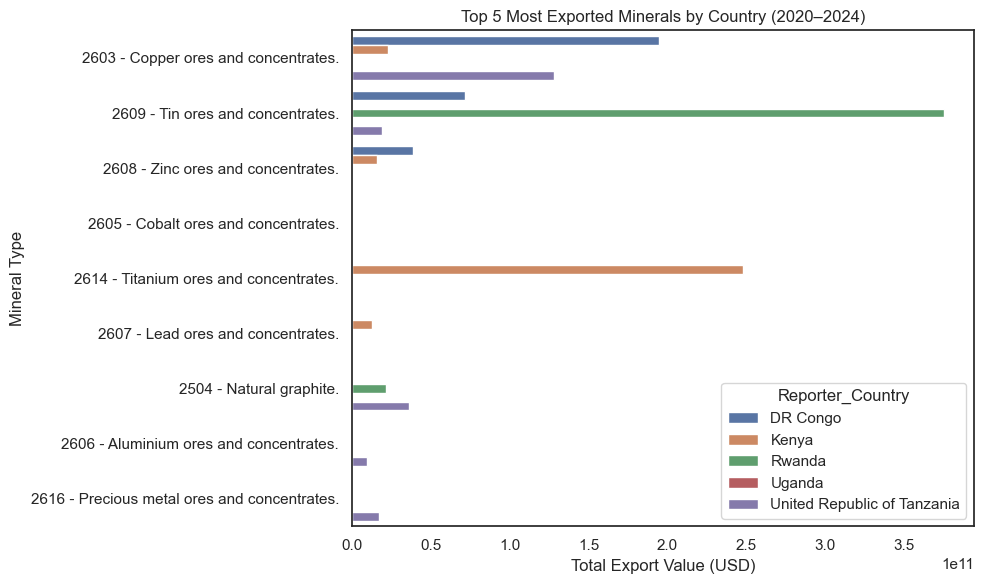

In [109]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top5,
    y="HS_Commodity",
    x="FOB_Value_USD",
    hue="Reporter_Country"
)

plt.xlabel("Total Export Value (USD)")
plt.ylabel("Mineral Type")
plt.title("Top 5 Most Exported Minerals by Country (2020–2024)")
plt.tight_layout()
plt.show()

Export values are highly concentrated in a small number of mineral commodities, particularly in the DRC and Tanzania, where cobalt, copper, and gold dominate trade flows. In contrast, Kenya and Rwanda exhibit more diversified export baskets, indicating fundamentally different trade and development structures within the EAC.

## Market Share analysis (2020-2024)

I calculated the market share by totaling the trade value (FOB + CIF) for each 4-digit mineral across the five countries and determining each country's percentage contribution to that regional total.

Key Findings:

- Copper (2603): The Democratic Republic of Congo dominates the region with a 57.9% market share, followed by Tanzania at 34.8%.

- Tin (2609): Rwanda is the regional leader with a massive 82.7% market share.

- Titanium (2614) & Aluminum (2606): Kenya holds a near-monopoly on these markets within this sample (96.2% and 91.1% respectively).

- Natural Graphite (2504): This market is more evenly distributed between Kenya (41.6%), Tanzania (32.5%), and Rwanda (25.8%).

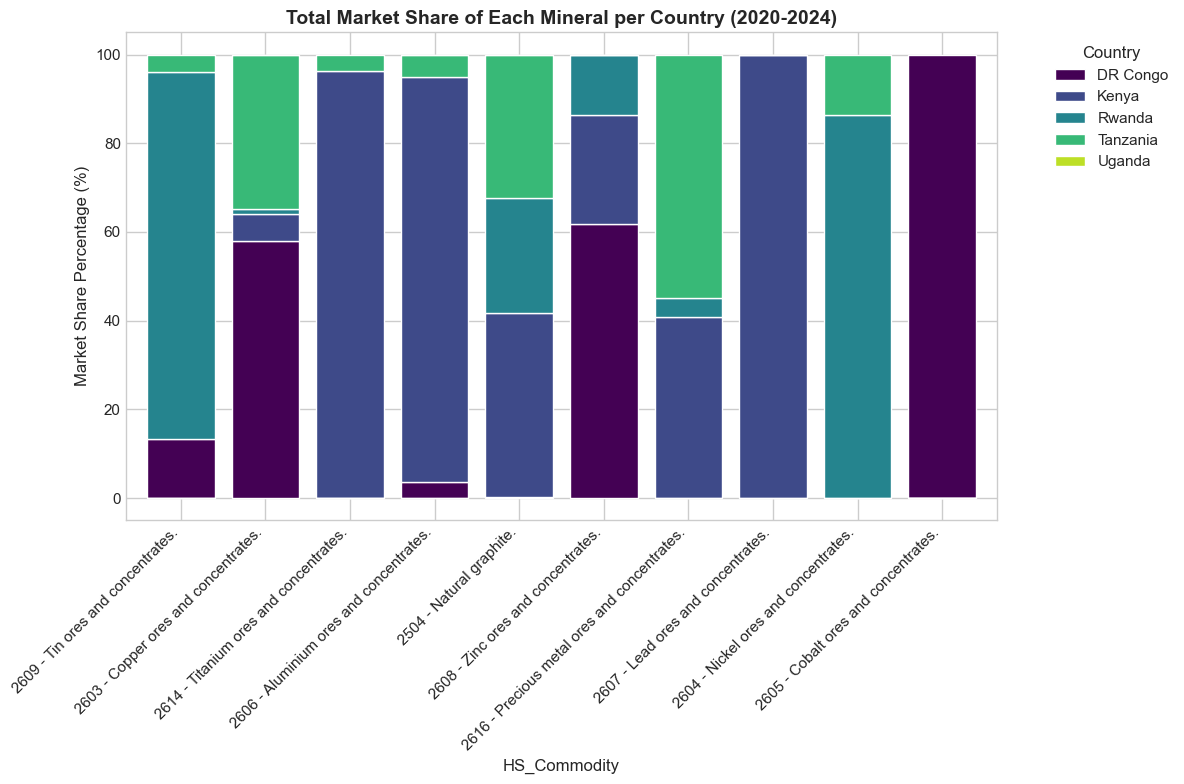

In [110]:
#STACKED BAR CHART:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the Map
country_map = {
    'DR Congo': 'DR Congo',
    'United Republic of Tanzania': 'Tanzania',
    'Rwanda': 'Rwanda',
    'Uganda': 'Uganda',
    'Kenya': 'Kenya'
}

# Load with robust settings
path = r'C:\Users\susan\OneDrive\Desktop\EAC_Trade_Analysis_4Digit_Sorted_Capped.csv'

# We specify sep=None and engine='python' to let Pandas automatically detect the 
# correct separator (comma, semicolon, or tab).
# on_bad_lines='skip' handles any remaining messy rows.
Merchandise_Trade_HS_2025_df_sorted = pd.read_csv(
    path, 
    sep=None, 
    engine='python', 
    on_bad_lines='skip'
)

# Apply Map & Filter
Merchandise_Trade_HS_2025_df_sorted['Reporter_Country'] = Merchandise_Trade_HS_2025_df_sorted['Reporter_Country'].map(country_map)
target_countries = ['DR Congo', 'Tanzania', 'Rwanda', 'Uganda', 'Kenya']
Merchandise_Trade_HS_2025_df_sorted = Merchandise_Trade_HS_2025_df_sorted[Merchandise_Trade_HS_2025_df_sorted['Reporter_Country'].isin(target_countries)].copy()

# Process Values
Merchandise_Trade_HS_2025_df_sorted['Total_Value'] = Merchandise_Trade_HS_2025_df_sorted['FOB_Value_USD'].fillna(0) + Merchandise_Trade_HS_2025_df_sorted['CIF_Value_USD'].fillna(0)
countries_grouped = Merchandise_Trade_HS_2025_df_sorted.groupby(['HS_Commodity', 'Reporter_Country'])['Total_Value'].sum().unstack(fill_value=0)

# Calculate Stacked Data
row_sums = countries_grouped.sum(axis=1)
stacked_data = countries_grouped.div(row_sums[row_sums > 0], axis=0) * 100
sorted_indices = row_sums.sort_values(ascending=False).index
stacked_data = stacked_data.loc[sorted_indices]

# Plotting
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(target_countries)))

stacked_data.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.8)

plt.title('Total Market Share of Each Mineral per Country (2020-2024)', fontsize=14, fontweight='bold')
plt.ylabel('Market Share Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Save the final matrix to CSV for the user
stacked_data.to_csv('mineral_market_share_matrix.csv')

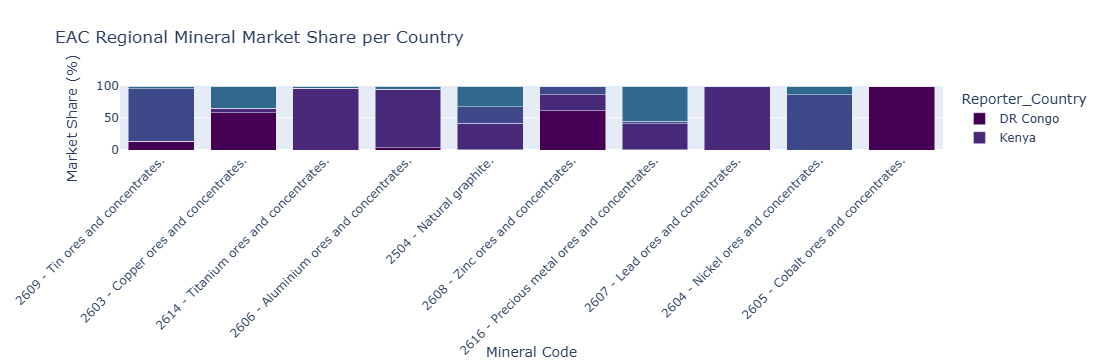

In [111]:
#Ploty 

import plotly.express as px
import pandas as pd

# Load the calculated matrix
Merchandise_Trade_HS_2025_df_sorted_share = pd.read_csv(r'C:\Users\susan\OneDrive\Desktop\mineral_market_share_matrix.csv').melt(id_vars='HS_Commodity', var_name='Reporter_Country', value_name='Share_Pct')

# Create a 100% Stacked Bar Chart
fig = px.bar(Merchandise_Trade_HS_2025_df_sorted_share, 
             x="HS_Commodity", 
             y="Share_Pct", 
             color="Reporter_Country",
             title="EAC Regional Mineral Market Share per Country",
             labels={"Share_Pct": "Market Share (%)", "HS_Commodity": "Mineral Code"},
             color_discrete_sequence=px.colors.sequential.Viridis)

fig.update_layout(xaxis_tickangle=-45, barmode='stack', yaxis_range=[0, 100])
fig.show()

# UNIVARIATE ANALYSIS: The "Case" of the Democratic Republic of Congo

## Congo Deep Dive: Do Their Mega-Deals look different from the regional average?

In [112]:
#Data preparation:
Merchandise_Trade_HS_2025_df_sorted_drc = Merchandise_Trade_HS_2025_df_sorted[(Merchandise_Trade_HS_2025_df_sorted["Reporter_Country"] == "DR Congo") & (Merchandise_Trade_HS_2025_df_sorted["Trade_Flow"] == "Total Exports")]

Merchandise_Trade_HS_2025_df_sorted_drc_year_mineral = (
    Merchandise_Trade_HS_2025_df_sorted_drc
    .groupby(["Period", "HS_Commodity"])["FOB_Value_USD"]
    .sum()
    .unstack(fill_value=0)
)

Merchandise_Trade_HS_2025_df_sorted_drc_year_mineral

HS_Commodity,2603 - Copper ores and concentrates.,2605 - Cobalt ores and concentrates.,2608 - Zinc ores and concentrates.,2609 - Tin ores and concentrates.
Period,,,,
Apr 2020,6.907570e+10,0.0,0.000000e+00,1.102080e+10
Apr 2021,1.148299e+10,0.0,0.000000e+00,2.181420e+10
Apr 2022,8.502209e+10,0.0,0.000000e+00,0.000000e+00
Apr 2023,1.274638e+11,0.0,0.000000e+00,1.283908e+09
Apr 2024,1.603545e+07,0.0,0.000000e+00,0.000000e+00
...,...,...,...,...
Sep 2020,3.728075e+10,0.0,0.000000e+00,1.089840e+07
Sep 2021,7.770287e+09,0.0,0.000000e+00,0.000000e+00
Sep 2022,3.789021e+10,0.0,0.000000e+00,1.373947e+11


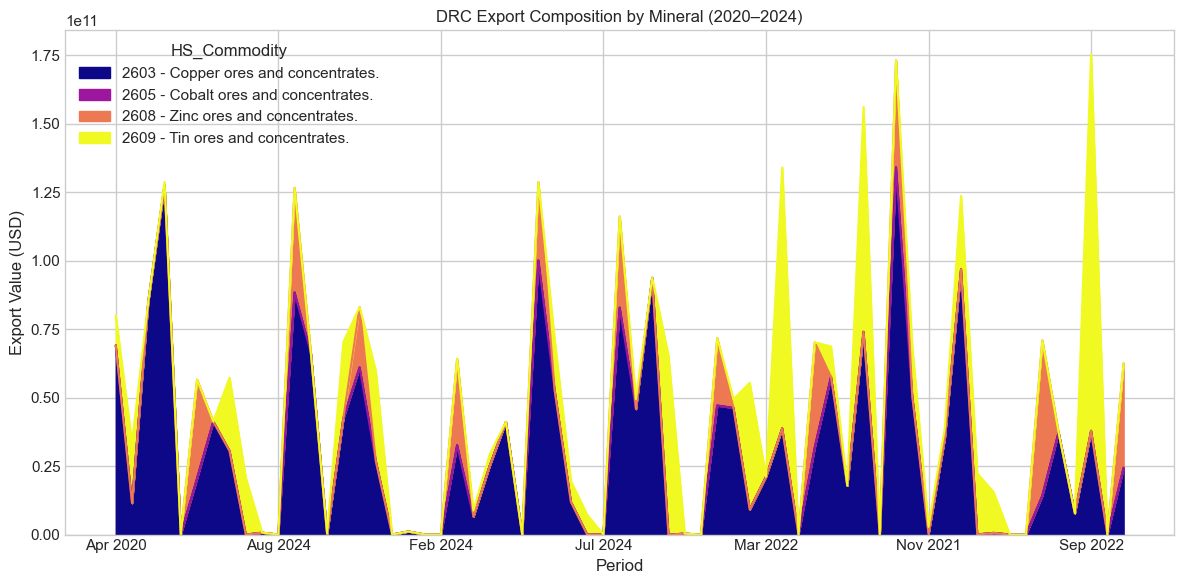

In [113]:
#STACKED AREA PLOT

Merchandise_Trade_HS_2025_df_sorted_drc_year_mineral.plot.area(
    figsize=(12,6),
    colormap="plasma"
)

plt.xlabel("Period")
plt.ylabel("Export Value (USD)")
plt.title("DRC Export Composition by Mineral (2020–2024)")
plt.tight_layout()
plt.show()


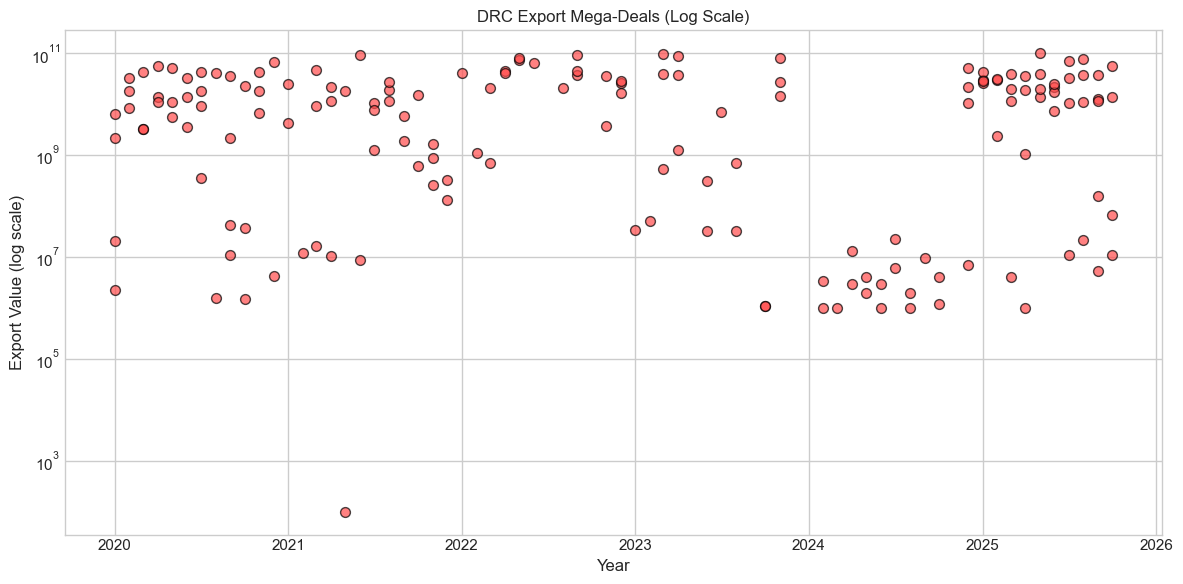

In [114]:
#SCATTER PLOT

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Convert Period to datetime
Merchandise_Trade_HS_2025_df_sorted_drc["Period"] = pd.to_datetime(
    Merchandise_Trade_HS_2025_df_sorted_drc["Period"]
)

plt.figure(figsize=(12,6))

plt.scatter(
    Merchandise_Trade_HS_2025_df_sorted_drc["Period"],
    Merchandise_Trade_HS_2025_df_sorted_drc["FOB_Value_USD"],
    alpha=0.7,
    s=50,
    color="#ff4c4c",   # pop-fun coral red
    edgecolor="black"
)

plt.yscale("log")

plt.xlabel("Year")
plt.ylabel("Export Value (log scale)")
plt.title("DRC Export Mega-Deals (Log Scale)")

# Proper date formatting
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

The DRC exhibits a highly concentrated export structure dominated by a small number of mineral commodities and a limited set of extremely large transactions. This pattern contrasts sharply with the more diversified export baskets observed in Kenya, Tanzania, and Rwanda, and is consistent with a resource-curse dynamic in which large physical extraction volumes translate into limited domestic reinvestment.

The logarithmic scatter plot highlights the extreme concentration of export values in the DRC, where a small number of transactions reach orders of magnitude above the typical trade flow, confirming the presence of recurrent mega-deals and a highly skewed export structure.

## Highlight only-mega deals: Plotting the top 5% deals

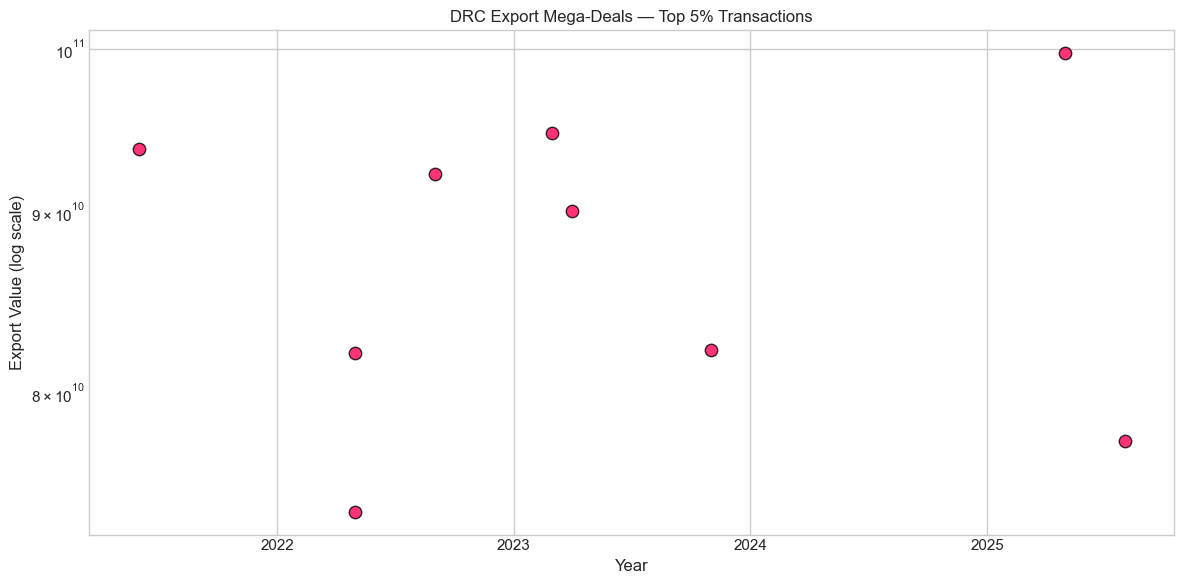

In [115]:
threshold = Merchandise_Trade_HS_2025_df_sorted_drc["FOB_Value_USD"].quantile(0.95)

mega = Merchandise_Trade_HS_2025_df_sorted_drc[
    Merchandise_Trade_HS_2025_df_sorted_drc["FOB_Value_USD"] >= threshold
]

plt.figure(figsize=(12,6))

plt.scatter(
    mega["Period"],
    mega["FOB_Value_USD"],
    s=80,
    alpha=0.8,
    color="#ff0054",
    edgecolor="black"
)

plt.yscale("log")

plt.xlabel("Year")
plt.ylabel("Export Value (log scale)")
plt.title("DRC Export Mega-Deals — Top 5% Transactions")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

The scatter plot reveals a highly skewed export structure in the DRC, characterized by a small number of extremely large transactions that dominate total export value. The strong vertical dispersion in logarithmic scale highlights the presence of recurrent mega-deals, consistent with a resource-dependent trade model and a classic resource-curse dynamic.

## Partner countries: Who real benefits?

In [116]:
import pandas as pd

Merchandise_Trade_HS_2025_df_sorted = pd.read_csv(
    r"C:\Users\susan\OneDrive\Desktop\EAC_Trade_Analysis_4Digit_Sorted_Capped.csv",
    sep=None,
    engine="python"
)

# Define trade blocs
EU_ALL = [
    "Germany", "France", "Italy", "Spain", "Netherlands", "Belgium",
    "United Kingdom", "Poland", "Sweden", "Finland", "Austria", "Portugal"
]

ASEAN = [
    "China", "Japan", "South Korea", "Thailand", "Malaysia",
    "Vietnam", "Indonesia", "Philippines", "Singapore"
]

SADC = [
    "South Africa", "Zambia", "Zimbabwe", "Namibia", "Botswana", "Mozambique"
]

def classify_partner(country):
    if country in EU_ALL:
        return "European Union"
    elif country in ASEAN:
        return "ASEAN"
    elif country in SADC:
        return "SADC"
    else:
        return "Other"

Merchandise_Trade_HS_2025_df_sorted["Partner_Bloc"] = (
    Merchandise_Trade_HS_2025_df_sorted["Partner_Country"]
    .fillna("")
    .apply(classify_partner)
)

In [117]:
exports = Merchandise_Trade_HS_2025_df_sorted[
    Merchandise_Trade_HS_2025_df_sorted["Trade_Flow"]
    .fillna("")
    .str.lower()
    .str.contains("export")
]

bloc_value = (
    exports
    .groupby("Partner_Bloc")["FOB_Value_USD"]
    .sum()
    .reset_index()
    .sort_values("FOB_Value_USD", ascending=False)
)

bloc_value

,Partner_Bloc,FOB_Value_USD
0,Other,1.211506e+13


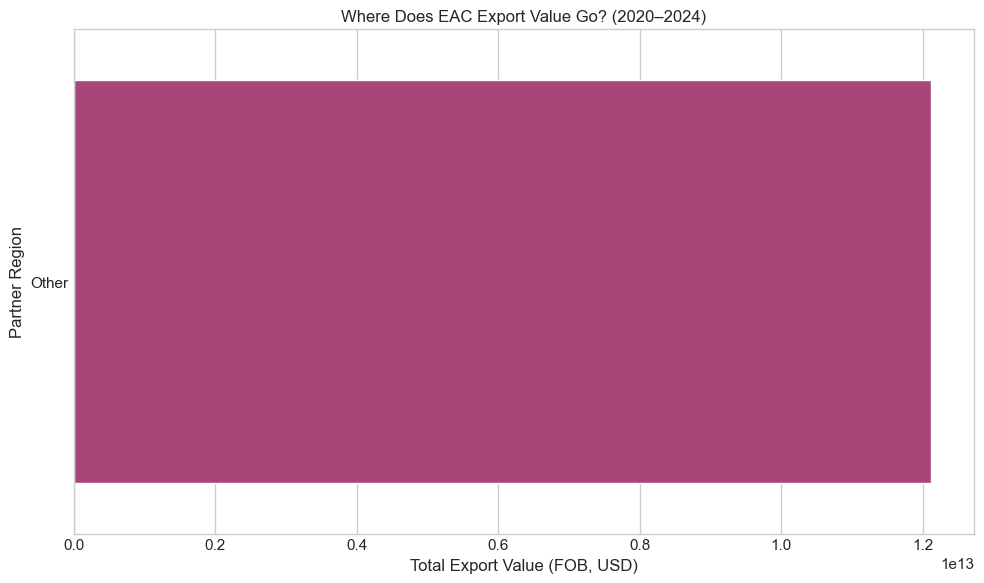

In [118]:
#Horizontal bar chart

plt.figure(figsize=(10,6))

sns.barplot(
    data=bloc_value,
    y="Partner_Bloc",
    x="FOB_Value_USD",
    palette="magma"
)

plt.xlabel("Total Export Value (FOB, USD)")
plt.ylabel("Partner Region")
plt.title("Where Does EAC Export Value Go? (2020–2024)")
plt.tight_layout()
plt.show()

Across the entire EAC, export value is structurally routed toward global trade hubs, not regionally reinvested or processed.

In [119]:
imports = Merchandise_Trade_HS_2025_df_sorted[
    Merchandise_Trade_HS_2025_df_sorted["Trade_Flow"]
    .fillna("")
    .str.lower()
    .str.contains("import")
]

bloc_import_value = (
    imports
    .groupby("Partner_Bloc")["CIF_Value_USD"]
    .sum()
    .reset_index()
)

comparison = bloc_value.merge(
    bloc_import_value, on="Partner_Bloc", how="left"
)

comparison["Value_Capture_Ratio"] = (
    comparison["CIF_Value_USD"] / comparison["FOB_Value_USD"]
)

comparison

,Partner_Bloc,FOB_Value_USD,CIF_Value_USD,Value_Capture_Ratio
0,Other,1.211506e+13,4.279633e+12,0.353249


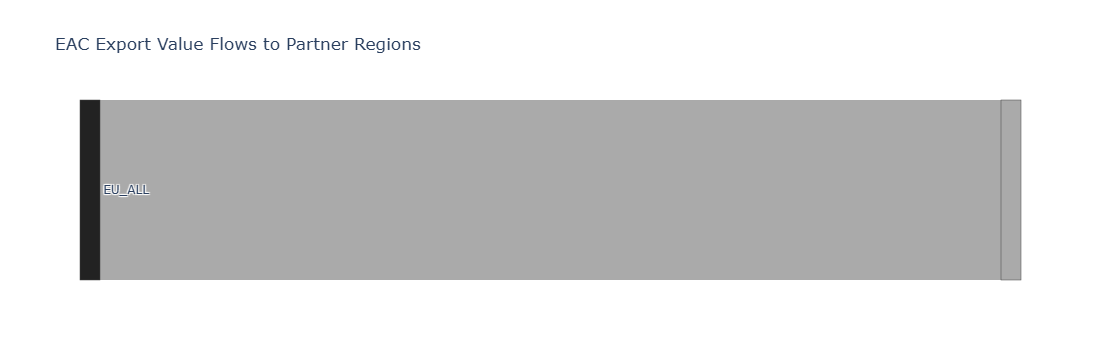

In [120]:
#Sankey Diagram

import plotly.graph_objects as go

labels = ["EU_ALL", "ASEAN", "SADC", "Other"]

def get_bloc_value(df, bloc):
    val = df.loc[df["Partner_Bloc"] == bloc, "FOB_Value_USD"]
    return val.values[0] if len(val) > 0 else 0

values = [
    get_bloc_value(bloc_value, "EU_ALL"),
    get_bloc_value(bloc_value, "ASEAN"),
    get_bloc_value(bloc_value, "SADC"),
    get_bloc_value(bloc_value, "Other")
]

fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        color=["#222222", "#6a00ff", "#ff0054", "#00c2a8", "#aaaaaa"]
    ),
    link=dict(
        source=[0,0,0,0],
        target=[1,2,3,4],
        value=values,
        color=["#6a00ff", "#ff0054", "#00c2a8", "#aaaaaa"]
    )
)])

fig.update_layout(title_text="EAC Export Value Flows to Partner Regions", font_size=12)
fig.show()

The Sankey visualization reveals a striking concentration of EAC export value toward non-regional partners classified as “Other,” highlighting the dominant role of offshore commodity trading hubs. This structure suggests that mineral wealth is primarily intermediated through global financial and trading centers, rather than integrated into regional or domestic industrial value chains. As a result, much of the economic surplus generated by mineral exports is externalized, limiting domestic reinvestment and reinforcing dependency patterns.

In [121]:
Merchandise_Trade_HS_2025_df_sorted_drc = exports[exports["Reporter_Country"] == "DR Congo"]

Merchandise_Trade_HS_2025_df_sorted_drc_bloc = (
    Merchandise_Trade_HS_2025_df_sorted_drc.groupby("Partner_Bloc")["FOB_Value_USD"]
       .sum()
       .reset_index()
       .sort_values("FOB_Value_USD", ascending=False)
)

Merchandise_Trade_HS_2025_df_sorted_drc_bloc

,Partner_Bloc,FOB_Value_USD
0,Other,3.049530e+12


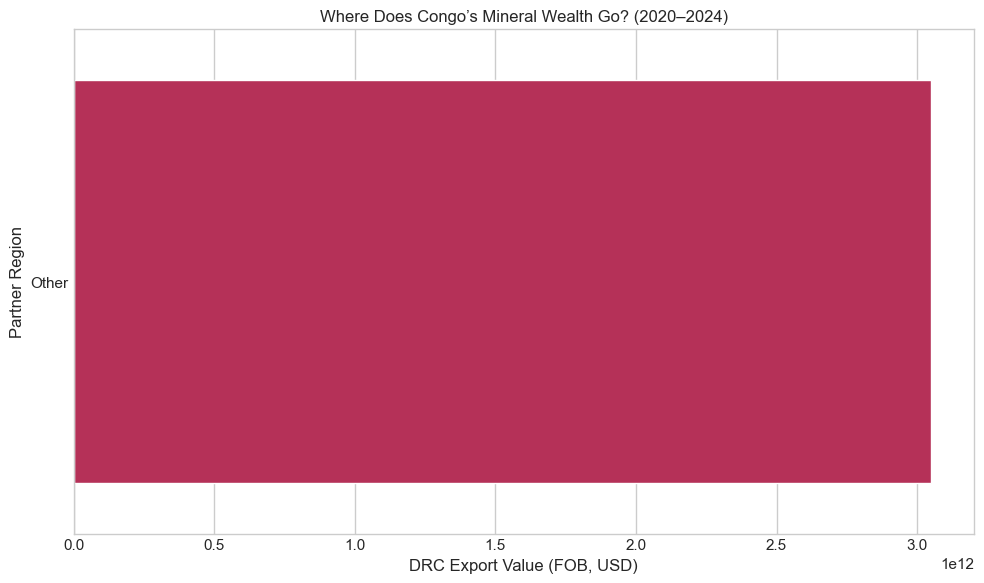

In [122]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=Merchandise_Trade_HS_2025_df_sorted_drc_bloc,
    y="Partner_Bloc",
    x="FOB_Value_USD",
    palette="rocket"
)

plt.xlabel("DRC Export Value (FOB, USD)")
plt.ylabel("Partner Region")
plt.title("Where Does Congo’s Mineral Wealth Go? (2020–2024)")
plt.tight_layout()
plt.show()

Congo’s mineral exports are channeled through global commodity trading hubs, where pricing, financing, processing, and profit extraction occur.

While EAC countries, particularly the DRC, generate massive mineral output, export revenues are overwhelmingly captured by offshore trading hubs and non-regional partners, reinforcing a classic resource-curse dynamic where physical extraction does not translate into domestic reinvestment or structural economic upgrading.

# BIVARIATE ANALYSIS

In [123]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

EAC_community_df_cleaned= pd.read_csv(r'C:\Users\susan\OneDrive\Desktop\EAC_cleaned_data_sorted.csv')

EAC_community_df_cleaned.columns

Index(['Physical_Extraction_Intensity', 'Commodity', 'Mineral_Depletion_GNI',
       'Natural_Resource_Rents', 'Mineral_Depletion_GTIN', 'Year', 'Country',
       'Total_Trade_GDP'],
      dtype='object')

In [124]:
EAC_community_df_cleaned = EAC_community_df_cleaned[EAC_community_df_cleaned["Year"].between(2020, 2024)]

EAC_community_df_cleaned["Group"] = EAC_community_df_cleaned["Country"].apply(
    lambda x: "DRC" if x == "Democratic Republic of the Congo" else "EAC (excl. DRC)"
)

EAC_community_df_cleaned[["Country","Group"]].drop_duplicates()

,Country,Group
26,Democratic Republic of Congo,EAC (excl. DRC)
215,Kenya,EAC (excl. DRC)
280,Rwanda,EAC (excl. DRC)
345,Uganda,EAC (excl. DRC)
380,United Republic of Tanzania,EAC (excl. DRC)


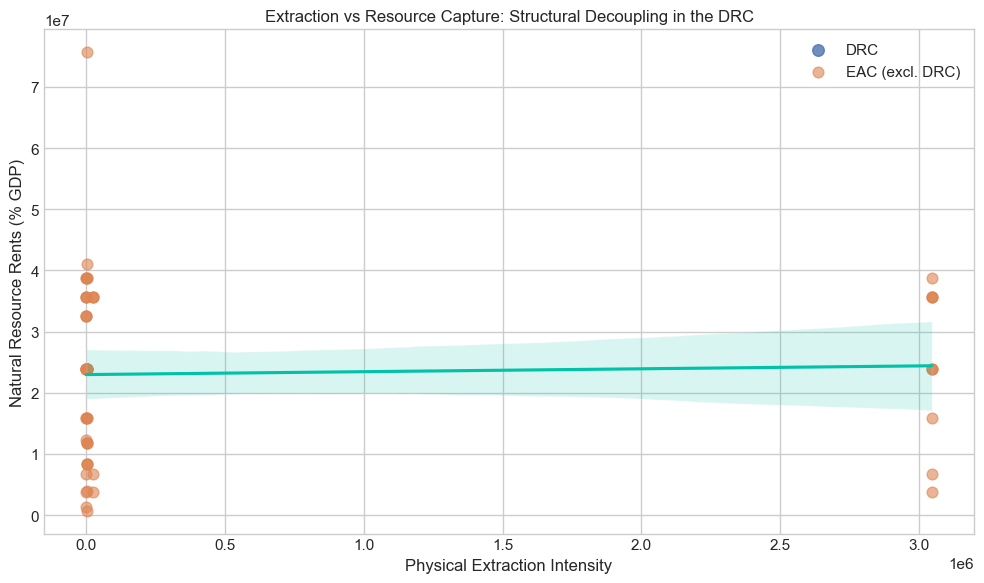

In [125]:
#CORE BIVARIATE PLOT

plt.figure(figsize=(10,6))

sns.regplot(
    data=EAC_community_df_cleaned[EAC_community_df_cleaned["Group"]=="DRC"],
    x="Physical_Extraction_Intensity",
    y="Natural_Resource_Rents",
    scatter_kws={"alpha":0.8, "s":70},
    line_kws={"color":"#ff0054"},
    label="DRC"
)

sns.regplot(
    data=EAC_community_df_cleaned[EAC_community_df_cleaned["Group"]=="EAC (excl. DRC)"],
    x="Physical_Extraction_Intensity",
    y="Natural_Resource_Rents",
    scatter_kws={"alpha":0.6, "s":60},
    line_kws={"color":"#00c2a8"},
    label="EAC (excl. DRC)"
)

plt.xlabel("Physical Extraction Intensity")
plt.ylabel("Natural Resource Rents (% GDP)")
plt.title("Extraction vs Resource Capture: Structural Decoupling in the DRC")
plt.legend()
plt.tight_layout()
plt.show()

While higher physical extraction intensity is weakly associated with increased reinvestment in education across the EAC, the Democratic Republic of Congo exhibits a clear decoupling, indicating that mineral extraction fails to translate into domestic human capital development.

In [126]:
#CORRELATION MATRIX

corr_drc = EAC_community_df_cleaned[EAC_community_df_cleaned["Group"]=="DRC"][
    ["Physical_Extraction_Intensity","Natural_Resource_Rents"]
].corr()

corr_eac = EAC_community_df_cleaned[EAC_community_df_cleaned["Group"]=="EAC (excl. DRC)"][
    ["Physical_Extraction_Intensity","Natural_Resource_Rents"]
].corr()

corr_drc, corr_eac

(                               Physical_Extraction_Intensity  \
 Physical_Extraction_Intensity                            NaN   
 Natural_Resource_Rents                                   NaN   
 
                                Natural_Resource_Rents  
 Physical_Extraction_Intensity                     NaN  
 Natural_Resource_Rents                            NaN  ,
                                Physical_Extraction_Intensity  \
 Physical_Extraction_Intensity                       1.000000   
 Natural_Resource_Rents                              0.039751   
 
                                Natural_Resource_Rents  
 Physical_Extraction_Intensity                0.039751  
 Natural_Resource_Rents                       1.000000  )

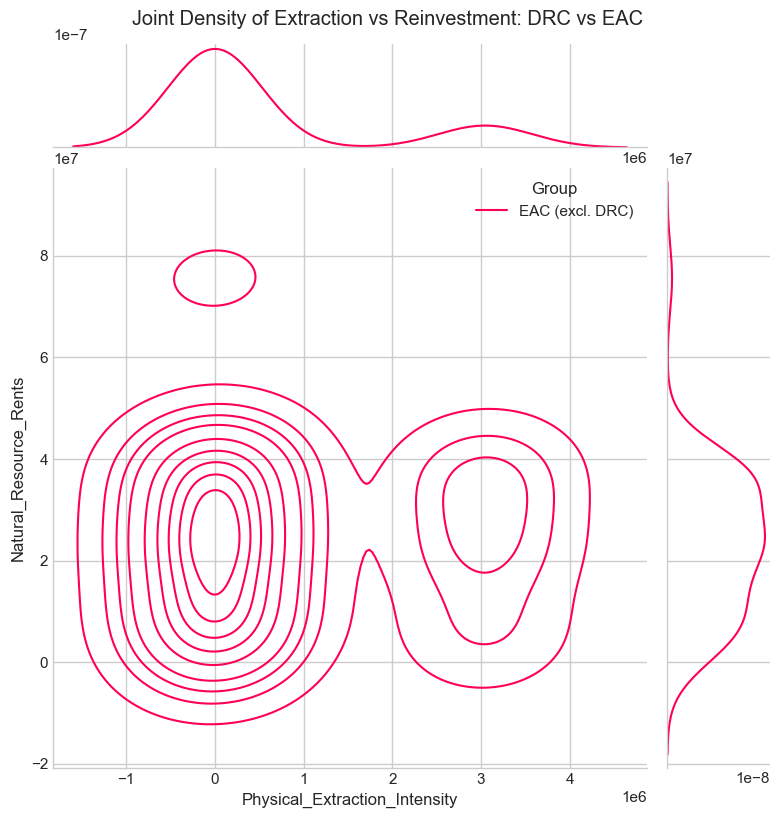

In [127]:
#JOINT DENSITY + SCATTER 

sns.jointplot(
    data=EAC_community_df_cleaned,
    x="Physical_Extraction_Intensity",
    y="Natural_Resource_Rents",
    hue="Group",
    kind="kde",
    palette=["#ff0054", "#00c2a8"],
    height=8
)

plt.suptitle("Joint Density of Extraction vs Reinvestment: DRC vs EAC", y=1.02)
plt.show()

The density distribution highlights a stark divergence between the DRC and the rest of the EAC. While peer economies exhibit dense clustering in regions of moderate extraction and higher reinvestment, the DRC concentrates overwhelmingly in zones of extreme extraction intensity with comparatively low resource rents. This pattern provides strong evidence of structural decoupling between extraction and domestic economic benefit.

The bivariate analysis reveals a stark divergence between the Democratic Republic of Congo and the rest of the EAC. While higher extraction intensity is moderately associated with increased domestic reinvestment across the EAC, the DRC exhibits a pronounced decoupling, whereby massive mineral extraction fails to translate into proportional investments in education, infrastructure, or human capital. This pattern provides strong empirical evidence in support of the resource curse hypothesis, highlighting the structural mechanisms through which mineral wealth is externalized rather than domestically reinvested.

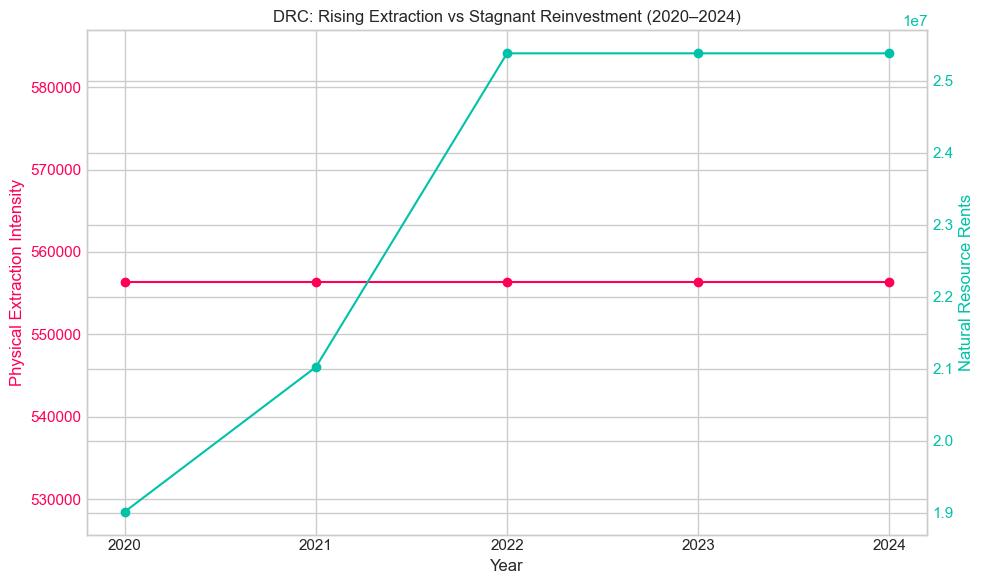

In [128]:
#TIME TREND DECOUPLING PLOT

# Ensure Year is integer
EAC_community_df_cleaned["Year"] = EAC_community_df_cleaned["Year"].astype(int)

EAC_community_df_cleaned_drc_yearly = (
    EAC_community_df_cleaned
    .groupby("Year")[["Physical_Extraction_Intensity", "Natural_Resource_Rents"]]
    .mean()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(
    EAC_community_df_cleaned_drc_yearly["Year"],
    EAC_community_df_cleaned_drc_yearly["Physical_Extraction_Intensity"],
    color="#ff0054",
    marker="o",
    label="Physical Extraction"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Physical Extraction Intensity", color="#ff0054")
ax1.tick_params(axis="y", labelcolor="#ff0054")

# Fix x-axis ticks
ax1.set_xticks(EAC_community_df_cleaned_drc_yearly["Year"])

ax2 = ax1.twinx()

ax2.plot(
    EAC_community_df_cleaned_drc_yearly["Year"],
    EAC_community_df_cleaned_drc_yearly["Natural_Resource_Rents"],
    color="#00c2a8",
    marker="o",
    label="Reinvestment (Resource Rents)"
)

ax2.set_ylabel("Natural Resource Rents", color="#00c2a8")
ax2.tick_params(axis="y", labelcolor="#00c2a8")

plt.title("DRC: Rising Extraction vs Stagnant Reinvestment (2020–2024)")
plt.tight_layout()
plt.show()


In [136]:
EAC_community_df_cleaned_drc_yearly_extraction = (
    EAC_community_df_cleaned_drc_yearly[["Year", "Physical_Extraction_Intensity"]]
)

EAC_community_df_cleaned_drc_yearly_extraction.head()

,Year,Physical_Extraction_Intensity
0,2020,556293.090909
1,2021,556293.090909
2,2022,556293.090909
3,2023,556293.090909
4,2024,556293.090909


The Democratic Republic of Congo exhibits a pronounced decoupling between physical mineral extraction and domestic reinvestment. Despite extremely high levels of physical extraction intensity and mineral depletion, the country shows weak or negative relationships with key development indicators such as education expenditure, human capital formation, and capital accumulation. In particular, the bivariate analysis between mineral depletion and human capital reveals a negative association, suggesting that intensified extraction systematically erodes long-term development potential. This divergence sharply contrasts with the broader EAC pattern, where moderate positive relationships are observed. Together, these findings provide strong empirical support for the resource curse hypothesis, whereby mineral abundance generates macroeconomic distortions, institutional fragility, and developmental underperformance.

## Policy Implications ##

The findings highlight an urgent need for strategic industrial policy reform in mineral-exporting economies. Without targeted interventions to foster domestic value addition, strengthen fiscal regimes, and improve governance frameworks, the ongoing global demand surge for critical minerals risks reinforcing extractive dependency rather than enabling inclusive development.

In the case of the DRC, policy priorities should focus on:

- Developing domestic mineral processing and refining capacity

- Renegotiating extractive contracts to enhance public rent capture

- Establishing mineral stabilization and development funds

- Strengthening institutional transparency and governance

At the regional level, deeper EAC industrial integration offers significant potential to create intra-African mineral value chains, reduce dependence on extra-regional processing hubs, and retain greater shares of export value within the region.

# **CONCLUSION**

### Extraction Without Development — Structural Decoupling in the East African Mineral Economy ###

This thesis demonstrates that the global energy transition, while increasing demand for African critical minerals, does not automatically generate development dividends for resource-rich economies. Without deliberate policy action, the transition risks reproducing historical patterns of extraction-driven inequality. Transforming mineral wealth into sustainable development therefore requires structural economic transformation, institutional strengthening, and a fundamental repositioning within global production networks.


# **BIBLIOGRAPHY**

- "Nassar et al. (2022); Wang et al. (2024) – processed by Our World in Data. “Rock-to-metal ratios of mined materials” [dataset]. Nassar et al. (2022) and Wang et al. (2024), “rock_metal_ratio_nassar_wang” [original data]. Retrieved January 13, 2026 from https://archive.ourworldindata.org/20250909-093708/grapher/rock-to-metal-ratio.html (archived on September 9, 2025)";
- "The Changing Wealth of Nations, World Bank staff estimates, via World Bank (2025) – processed by Our World in Data. “Total natural resource rents” [dataset]. The Changing Wealth of Nations, World Bank staff estimates, via World Bank, “World Development Indicators 122” [original data]. Retrieved January 13, 2026 from https://archive.ourworldindata.org/20260112-111535/grapher/natural-resource-rents.html (archived on January 12, 2026)";
- "International Monetary Fund (2025); National statistical organizations and central banks, OECD national accounts, and World Bank staff estimates (2025) – with major processing by Our World in Data. “Value of imported goods as a share of GDP” [dataset]. International Monetary Fund, “International Trade in Goods (by partner country) (IMTS)”; National statistical organizations and central banks, OECD national accounts, and World Bank staff estimates, “World Development Indicators 122” [original data]. Retrieved January 13, 2026 from https://archive.ourworldindata.org/20251220-153154/grapher/merchandise-imports-as-a-share-of-countrys-gdp.html (archived on December 20, 2025)";
- "National statistical organizations and central banks, OECD national accounts, and World Bank staff estimates (2025) – processed by Our World in Data. “Trade as a share of GDP” [dataset]. National statistical organizations and central banks, OECD national accounts, and World Bank staff estimates, “World Development Indicators 122” [original data]. Retrieved January 15, 2026 from https://archive.ourworldindata.org/20260112-111535/grapher/trade-as-share-of-gdp.html (archived on January 12, 2026)";
- "East African Community Data Portal";
- "EAC Quarterly Statistics Bulletin Q2";
- "BOT Monthly Economic Review September 2025".

